# M11 — Global-Local Crop Fusion

**EEEM068 Applied Machine Learning — MaxViT-Tiny Global-Local Crop Fusion Ablation**

**Research question:** Does combining the complete retinal image with a deterministic local
candidate-region crop improve diabetic-retinopathy grading compared with the M07 global-image
MaxViT model?

**M11 is a controlled parallel ablation of M07 — the official reference is M07, not M09 or
M10.** M11 does not build on, initialise from, or depend on the trained M09 or M10 models in
any way; the local-crop candidate-generation *pipeline* is shared with M09/M10 (same
thresholds, same component filtering) purely as a scientific control, not as a dependency.

M07 uses one complete retinal image:

```
Global retinal image -> MaxViT -> classifier
```

M11 uses two views of the same image, fused through one **shared** backbone (not two
independent backbones):

```
Complete retinal image ---\
                            +--> shared MaxViT backbone --> concatenate features --> linear classifier
Candidate-region crop -----/
```

**The only conceptual change from M07 is: add one deterministic local candidate-region crop
and fuse its features with the global-image features.** M11 deliberately does *not* add:
M09's bounding-box guidance channel, M10's pseudo-mask channel, segmentation masks, attention
gates, an additional loss term, a learned detector, multiple local crops, or ensemble
averaging — those belong to other experiments, particularly a possible M12.

The crop used here is a **candidate-region crop** produced by a fixed, deterministic
classical image-processing pipeline — not a medically verified lesion crop. The internal test
set is not loaded anywhere in this notebook, and M11 trains from scratch from
ImageNet-pretrained weights; it does not load M07's, M09's, or M10's trained checkpoint.

| Setting | M11 value |
|---|---|
| Architecture | maxvit_tiny_tf_224.in1k (shared backbone, two views) |
| Pretraining | ImageNet |
| Seed | 42 |
| Classes | 5 |
| Image size | 224 × 224 |
| Maximum epochs | 25 |
| Warm-up epochs | 3 |
| Early-stopping patience | 7 |
| Learning rate | 5e-5 |
| Weight decay | 0.05 |
| Gradient clipping | 1.0 |
| Optimiser | AdamW |
| Scheduler | Linear warm-up then cosine decay |
| Class weighting | Clipped class-weighted CE, [0.5, 2.5] |
| Ordinal-loss coefficient | 0.5 |
| Sampler | Ordinary shuffle, no WRS |
| Physical batch size | 16 |
| Gradient accumulation | 2 (effective batch 32, matching M07) |
| Primary checkpoint metric | Validation QWK |
| Tie-break | Validation macro-F1 |
| Preprocessing | P0 |
| Internal test | Must not be loaded |

**Final M11 design:** M07's complete retinal image + one deterministic 256×256
candidate-region crop + one shared ImageNet-pretrained MaxViT backbone + feature
concatenation + linear five-class classifier.

## 2. Imports

In [1]:
import json
import random
from pathlib import Path

import cv2
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

from torchvision import transforms
import torchvision.transforms.functional as TF

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.utils.class_weight import compute_class_weight

print("Imports OK.")

Imports OK.


## 3. Experiment configuration

Runs before reproducibility/paths, since `SEED` is defined here and later cells depend on it.
Every M07 control is copied verbatim (see the table in Section 1) — **M07 is the reference
this notebook is compared against, not M09 or M10.** The candidate-generation thresholds are
the same ones M09/M10 use, fixed before any validation result is examined, purely as a
control so the crop-selection *pipeline* isn't itself a confound.

In [2]:
EXPERIMENT_ID = "M11"
RUN_NAME = "M11_global_local_crop_fusion"
EXPERIMENT_TYPE = "global_local_crop_fusion_ablation"
REFERENCE_EXPERIMENT = "M07"
PREDECESSOR_EXPERIMENT = "M07_ordinal_aware_loss"

MODEL_NAME = "maxvit_tiny_tf_224.in1k"
IMAGE_SIZE = 224
NUM_CLASSES = 5
CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]
SEED = 42

VIT_MEAN = (0.485, 0.456, 0.406)
VIT_STD = (0.229, 0.224, 0.225)

# Effective batch size of 32, matching M07, via gradient accumulation (Section 11).
PHYSICAL_BATCH_SIZE = 16
GRAD_ACCUMULATION_STEPS = 2
EFFECTIVE_BATCH_SIZE = PHYSICAL_BATCH_SIZE * GRAD_ACCUMULATION_STEPS

LEARNING_RATE = 5e-5
WEIGHT_DECAY = 0.05

MAX_EPOCHS = 25
WARMUP_EPOCHS = 3
EARLY_STOPPING_PATIENCE = 7

LABEL_SMOOTHING = 0.0
GRAD_CLIP = 1.0
QWK_TOLERANCE = 1e-4
NUM_WORKERS = 4

TRAINING_MODE = "single_stage"

USE_CLASS_WEIGHTS = True
USE_WRS = False
CLASS_WEIGHT_METHOD = "balanced"
CLASS_WEIGHT_CLIP_MIN = 0.5
CLASS_WEIGHT_CLIP_MAX = 2.5

ORDINAL_PENALTY_WEIGHT = 0.5

# Exact M07 safe-retinal augmentation.
HORIZONTAL_FLIP_PROBABILITY = 0.5
ROTATION_DEGREES = 7
BRIGHTNESS_JITTER = 0.05
CONTRAST_JITTER = 0.05
SATURATION_JITTER = 0.02
HUE_JITTER = 0.0
TRANSLATE_FRACTION = 0.02
SCALE_MIN = 0.98
SCALE_MAX = 1.02

# --- Same candidate-generation thresholds as M09/M10 (fixed before any validation result
# is examined) - a scientific control, not a dependency on M09/M10's trained results. ---
DETECTION_SIZE = 512
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)
BACKGROUND_SIGMA = 12.0
DARK_RESPONSE_PERCENTILE = 97.0

MIN_COMPONENT_AREA = 3
MAX_COMPONENT_AREA = 350
MAX_ASPECT_RATIO = 4.0
MAX_CANDIDATE_COMPONENTS = 12

# --- M11-specific: fixed local-crop rule. ---
LOCAL_CROP_SIZE = 256

print(f"Experiment : {EXPERIMENT_ID} / {RUN_NAME}")
print(f"Reference  : {REFERENCE_EXPERIMENT}  (not M09 or M10)")
print(f"LR={LEARNING_RATE}  WD={WEIGHT_DECAY}  "
      f"PHYSICAL_BATCH={PHYSICAL_BATCH_SIZE}  ACCUM={GRAD_ACCUMULATION_STEPS}  "
      f"EFFECTIVE_BATCH={EFFECTIVE_BATCH_SIZE}")
print(f"MAX_EPOCHS={MAX_EPOCHS}  PATIENCE={EARLY_STOPPING_PATIENCE}")

Experiment : M11 / M11_global_local_crop_fusion
Reference  : M07  (not M09 or M10)
LR=5e-05  WD=0.05  PHYSICAL_BATCH=16  ACCUM=2  EFFECTIVE_BATCH=32
MAX_EPOCHS=25  PATIENCE=7


## 4. Reproducibility and device

In [3]:
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

if device.type != "cuda":
    raise RuntimeError(
        "CUDA GPU is not available. Do not start this training run on CPU."
    )

Device: cuda
GPU: NVIDIA RTX A4000


## 5. Paths and output directories

`M07_LOG_DIR` is the notebook's actual experimental reference. `M09_LOG_DIR`/`M10_LOG_DIR`
are only used for the optional, purely descriptive comparisons in Section 21 — those
comparisons never influence M11's training and are skipped gracefully if unavailable.

In [4]:
PROJECT_ROOT = Path(
    "/scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy"
)

SPLITS_DIR = PROJECT_ROOT / "configs" / "splits"

TRAIN_CSV = SPLITS_DIR / "train_split.csv"
VAL_CSV = SPLITS_DIR / "val_split.csv"
# The internal test split is intentionally not loaded anywhere in this
# notebook. It stays locked until a final MaxViT configuration is selected
# across the full M01-M11+ series.

LOG_DIR = PROJECT_ROOT / "logs" / "maxvit_tiny" / RUN_NAME
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / "maxvit_tiny" / RUN_NAME
FIGURE_DIR = PROJECT_ROOT / "results" / "figures" / "maxvit_tiny" / RUN_NAME

for directory in [LOG_DIR, CHECKPOINT_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / "best.pt"

M07_LOG_DIR = PROJECT_ROOT / "logs" / "maxvit_tiny" / PREDECESSOR_EXPERIMENT
M09_LOG_DIR = PROJECT_ROOT / "logs" / "maxvit_tiny" / "M09_detection_guided_regions"
M10_LOG_DIR = PROJECT_ROOT / "logs" / "maxvit_tiny" / "M10_pseudo_segmentation_guidance"

# Local, git-ignored cache of deterministic crop metadata/coordinates (Section 12).
# Recomputing candidate generation on every epoch would be wasted CPU time. Before running
# (not merely creating) this notebook, make sure the cache is git-ignored - the repo's
# .gitignore already generalises this to "cache/" for M09-M12.
CROP_CACHE_DIR = PROJECT_ROOT / "cache" / "maxvit_tiny" / "M11_local_crops"
CROP_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Run          : maxvit_tiny/{RUN_NAME}")
print(f"Logs         -> {LOG_DIR}")
print(f"Checkpoints  -> {CHECKPOINT_DIR}")
print(f"Figures      -> {FIGURE_DIR}")
print(f"M07 logs     -> {M07_LOG_DIR}  (official reference; checkpoint never loaded)")
print(f"M09 logs     -> {M09_LOG_DIR}  (optional descriptive comparison only)")
print(f"M10 logs     -> {M10_LOG_DIR}  (optional descriptive comparison only)")
print(f"Crop cache   -> {CROP_CACHE_DIR}  (git-ignored; not committed)")

Run          : maxvit_tiny/M11_global_local_crop_fusion
Logs         -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M11_global_local_crop_fusion
Checkpoints  -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/checkpoints/maxvit_tiny/M11_global_local_crop_fusion
Figures      -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M11_global_local_crop_fusion
M07 logs     -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M07_ordinal_aware_loss  (official reference; checkpoint never loaded)
M09 logs     -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M09_detection_guided_regions  (optional descriptive comparison only)
M10 logs     -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M10_pseudo_segmentation_guidance  (optional descriptive comparison only)
Crop cache   -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/cache/maxvit_tiny/M11_local_crops  (git-ignored; not committed)

## 6. M07 → M11 controlled-ablation audit

Runs **before crop generation and before any training**. Checks M11's own configuration
against M07's **saved** `config.json` (never M07's checkpoint). Two settings this audit
checks (`loss_function` and `scheduler`) are not yet built as live objects this early in the
notebook (those cells run later, in Sections 14 and 16), so this cell checks against the
exact literal values those cells are guaranteed to produce.

In [5]:
required_m07_files = [
    M07_LOG_DIR / "config.json",
    M07_LOG_DIR / "best_metrics.json",
    M07_LOG_DIR / "validation_metrics.json",
]

for required_file in required_m07_files:
    if not required_file.exists():
        raise FileNotFoundError(f"Required M07 file not found: {required_file}")

with open(M07_LOG_DIR / "config.json") as f:
    m07_config = json.load(f)

EXPECTED_LOSS_FUNCTION_LABEL = (
    "clipped_weighted_ce_plus_normalised_expected_squared_ordinal_penalty"
)
EXPECTED_SCHEDULER_CONFIG = {
    "name": "SequentialLR",
    "warmup_scheduler": "LinearLR",
    "warmup_start_factor": 0.1,
    "warmup_end_factor": 1.0,
    "warmup_epochs": WARMUP_EPOCHS,
    "main_scheduler": "CosineAnnealingLR",
}

controlled_checks = [
    ("model_name", m07_config["model_name"], MODEL_NAME),
    ("seed", m07_config["seed"], SEED),
    ("image_size", m07_config["image_size"], IMAGE_SIZE),
    ("num_classes", m07_config["num_classes"], NUM_CLASSES),
    ("learning_rate", m07_config["learning_rate"], LEARNING_RATE),
    ("weight_decay", m07_config["weight_decay"], WEIGHT_DECAY),
    ("warmup_epochs", m07_config["warmup_epochs"], WARMUP_EPOCHS),
    ("max_epochs", m07_config["max_epochs"], MAX_EPOCHS),
    ("early_stopping_patience", m07_config["early_stopping_patience"], EARLY_STOPPING_PATIENCE),
    ("label_smoothing", m07_config["label_smoothing"], LABEL_SMOOTHING),
    ("grad_clip", m07_config["grad_clip"], GRAD_CLIP),
    ("qwk_tolerance", m07_config["qwk_tolerance"], QWK_TOLERANCE),
    ("use_class_weights", m07_config["use_class_weights"], USE_CLASS_WEIGHTS),
    ("use_wrs", m07_config["use_wrs"], USE_WRS),
    ("sampler", m07_config["sampler"], "shuffle"),
    ("class_weight_method", m07_config["class_weight_method"], CLASS_WEIGHT_METHOD),
    ("class_weight_clip_min", m07_config["class_weight_clip_min"], CLASS_WEIGHT_CLIP_MIN),
    ("class_weight_clip_max", m07_config["class_weight_clip_max"], CLASS_WEIGHT_CLIP_MAX),
    ("loss_function", m07_config["loss_function"], EXPECTED_LOSS_FUNCTION_LABEL),
    ("ordinal_penalty_weight", m07_config["ordinal_penalty_weight"], ORDINAL_PENALTY_WEIGHT),
    ("optimizer", m07_config["optimizer"], "AdamW"),
    ("scheduler", m07_config["scheduler"], EXPECTED_SCHEDULER_CONFIG),
    ("selection_metric", m07_config["selection_metric"], "validation_qwk"),
    ("selection_tiebreak", m07_config["selection_tiebreak"], "validation_macro_f1"),
    ("training_mode", m07_config["training_mode"], TRAINING_MODE),
    ("preprocessing", m07_config["preprocessing"], "P0"),
    ("normalisation_mean", m07_config["normalisation_mean"], list(VIT_MEAN)),
    ("normalisation_std", m07_config["normalisation_std"], list(VIT_STD)),
    (
        "training_augmentation.horizontal_flip_probability",
        m07_config["training_augmentation"]["horizontal_flip_probability"],
        HORIZONTAL_FLIP_PROBABILITY,
    ),
    (
        "training_augmentation.rotation_degrees",
        m07_config["training_augmentation"]["rotation_degrees"],
        ROTATION_DEGREES,
    ),
    (
        "training_augmentation.brightness_jitter",
        m07_config["training_augmentation"]["brightness_jitter"],
        BRIGHTNESS_JITTER,
    ),
    (
        "training_augmentation.contrast_jitter",
        m07_config["training_augmentation"]["contrast_jitter"],
        CONTRAST_JITTER,
    ),
    (
        "training_augmentation.saturation_jitter",
        m07_config["training_augmentation"]["saturation_jitter"],
        SATURATION_JITTER,
    ),
    (
        "training_augmentation.hue_jitter",
        m07_config["training_augmentation"]["hue_jitter"],
        HUE_JITTER,
    ),
    ("translation_fraction", m07_config["training_augmentation"]["translation_fraction"], TRANSLATE_FRACTION),
    ("scale_min", m07_config["training_augmentation"]["scale_min"], SCALE_MIN),
    ("scale_max", m07_config["training_augmentation"]["scale_max"], SCALE_MAX),
    ("train_csv", m07_config["train_csv"], str(TRAIN_CSV)),
    ("val_csv", m07_config["val_csv"], str(VAL_CSV)),
]

audit_failures = []
for check_name, m07_value, m11_value in controlled_checks:
    if m07_value != m11_value:
        audit_failures.append((check_name, m07_value, m11_value))

if audit_failures:
    print("AUDIT FAILURES:")
    for check_name, m07_value, m11_value in audit_failures:
        print(f"  {check_name}: M07={m07_value!r}  M11={m11_value!r}")
    raise RuntimeError(
        f"{len(audit_failures)} controlled setting(s) differ between M07 and M11 - "
        "this is no longer a clean single-variable ablation."
    )

allowed_differences = [
    "experiment_identity", "run_output_paths", "two_view_dataset",
    "local_crop_configuration", "shared_backbone_fusion_classifier",
    "physical_batch_size_and_gradient_accumulation", "parameter_count_and_compute_cost",
]
print(f"Required M07 result files found: {len(required_m07_files)}/{len(required_m07_files)}")
print("Controlled settings verified identical to M07:")
for check_name, _, _ in controlled_checks:
    print(f"  - {check_name}")
print()
print("Allowed (intended) differences:", ", ".join(allowed_differences))
print()
print("M07 -> M11 controlled-ablation audit: PASSED")

Required M07 result files found: 3/3
Controlled settings verified identical to M07:
  - model_name
  - seed
  - image_size
  - num_classes
  - learning_rate
  - weight_decay
  - warmup_epochs
  - max_epochs
  - early_stopping_patience
  - label_smoothing
  - grad_clip
  - qwk_tolerance
  - use_class_weights
  - use_wrs
  - sampler
  - class_weight_method
  - class_weight_clip_min
  - class_weight_clip_max
  - loss_function
  - ordinal_penalty_weight
  - optimizer
  - scheduler
  - selection_metric
  - selection_tiebreak
  - training_mode
  - preprocessing
  - normalisation_mean
  - normalisation_std
  - training_augmentation.horizontal_flip_probability
  - training_augmentation.rotation_degrees
  - training_augmentation.brightness_jitter
  - training_augmentation.contrast_jitter
  - training_augmentation.saturation_jitter
  - training_augmentation.hue_jitter
  - translation_fraction
  - scale_min
  - scale_max
  - train_csv
  - val_csv

Allowed (intended) differences: experiment_identi

## 7. Load patient-grouped CSV files and verify zero patient overlap

In [6]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

required_columns = {"image", "level", "patient_id", "eye", "filepath"}

for split_name, frame in [("train", train_df), ("validation", val_df)]:
    missing_columns = required_columns - set(frame.columns)
    if missing_columns:
        raise ValueError(f"{split_name} is missing columns: {sorted(missing_columns)}")

    missing_files = frame.loc[~frame["filepath"].map(lambda path: Path(path).exists())]
    if len(missing_files) > 0:
        raise FileNotFoundError(
            f"{split_name} contains {len(missing_files):,} missing image files."
        )

train_patients = set(train_df["patient_id"])
val_patients = set(val_df["patient_id"])
assert train_patients.isdisjoint(val_patients), "Patient overlap detected."

print(f"Train      : {len(train_df):,}  ({len(train_patients):,} patients)")
print(f"Validation : {len(val_df):,}  ({len(val_patients):,} patients)")
print("Patient overlap check: PASSED (zero overlap)")

Train      : 24,586  (12,293 patients)
Validation : 5,270  (2,635 patients)
Patient overlap check: PASSED (zero overlap)


## 8. P0 preprocessing

Identical crop/pad pipeline used throughout the project. `preprocess_p0_full` returns the
cropped-and-padded (but not yet resized) square image — needed here because the candidate
detection pipeline (Section 9) works on its own 512×512 resize of this same crop, independent
of the 224×224 resize used for the global view.

In [7]:
def _load_rgb(path: str) -> np.ndarray:
    img_bgr = cv2.imread(str(path))
    if img_bgr is None:
        raise ValueError(f"Cannot decode image: {path}")
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def _crop_black_borders(img: np.ndarray, threshold: int = 10) -> np.ndarray:
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img
    x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
    margin = int(min(w, h) * 0.02)
    x, y = max(0, x - margin), max(0, y - margin)
    w = min(img.shape[1] - x, w + 2 * margin)
    h = min(img.shape[0] - y, h + 2 * margin)
    return img[y:y + h, x:x + w]


def _pad_square(img: np.ndarray) -> np.ndarray:
    h, w = img.shape[:2]
    side = max(h, w)
    canvas = np.zeros((side, side, 3), dtype=img.dtype)
    y = (side - h) // 2
    x = (side - w) // 2
    canvas[y:y + h, x:x + w] = img
    return canvas


def preprocess_p0_full(image_path: str) -> np.ndarray:
    """Load, crop black borders, pad to square. No resize yet - the caller decides the
    target resolution (224 for the global view, 512 for candidate detection)."""
    img = _load_rgb(image_path)
    img = _crop_black_borders(img)
    img = _pad_square(img)
    return img


print("P0 preprocessing ready (crop + pad; resize handled per-use downstream).")

P0 preprocessing ready (crop + pad; resize handled per-use downstream).


## 9. Deterministic candidate-region detection and fixed local-crop selection

Component-detection pipeline is **identical to M09/M10's**: resize the P0 crop to 512×512 →
green channel → CLAHE → Gaussian-blur background estimate → dark residual → percentile
threshold (restricted to the retinal field, with the same zero-response edge-case guard
M09/M10 use) → light morphological opening → connected components → reject components too
small, too large, or too elongated → rank by response strength → keep at most
`MAX_CANDIDATE_COMPONENTS`. Using the exact same thresholds and component logic as M09/M10 is
a deliberate scientific control on the *candidate-finding pipeline itself* — it is not a
dependency on M09's or M10's trained results, which M11 never uses.

**Where M11 diverges**: instead of turning every accepted component into a guidance channel
(M09: boxes, M10: exact pixels), M11 selects only the **single highest-ranked** accepted
component, takes its centroid, and centres one fixed 256×256 crop window there — shifting the
window inward if it would otherwise fall outside the 512×512 image, never resizing or
rotating the crop itself at this stage. If no component was accepted at all, M11 falls back
to the geometric centre 256×256 crop and records that the fallback was used. The crop is then
resized to 224×224 for the local branch. Crop selection never uses the DR label —
`select_local_crop(image)` only, never `select_local_crop(image, grade)`.

In [8]:
def _detect_candidate_components(image_rgb_full: np.ndarray) -> dict:
    """Shared component-detection core (identical thresholds/logic to M09/M10). Returns the
    ranked, filtered list of accepted components plus the intermediate arrays needed for
    crop selection and visualisation."""
    detection_image = cv2.resize(
        image_rgb_full, (DETECTION_SIZE, DETECTION_SIZE), interpolation=cv2.INTER_AREA
    )

    green = detection_image[:, :, 1]
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_GRID_SIZE)
    enhanced_green = clahe.apply(green)

    background = cv2.GaussianBlur(enhanced_green, (0, 0), BACKGROUND_SIGMA)
    dark_response = cv2.subtract(background, enhanced_green)

    gray = cv2.cvtColor(detection_image, cv2.COLOR_RGB2GRAY)
    field_mask = (gray > 10).astype(np.uint8)
    dark_response = dark_response * field_mask

    field_pixels = dark_response[field_mask > 0]

    if field_pixels.size == 0 or field_pixels.max() <= 0:
        threshold_value = 255.0
        binary = np.zeros_like(field_mask, dtype=np.uint8)
    else:
        threshold_value = float(np.percentile(field_pixels, DARK_RESPONSE_PERCENTILE))
        binary = (
            (dark_response >= threshold_value)
            & (dark_response > 0)
            & (field_mask > 0)
        ).astype(np.uint8) * 255

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

    candidates = []
    for label_id in range(1, num_labels):
        area = stats[label_id, cv2.CC_STAT_AREA]
        w = stats[label_id, cv2.CC_STAT_WIDTH]
        h = stats[label_id, cv2.CC_STAT_HEIGHT]

        if area < MIN_COMPONENT_AREA or area > MAX_COMPONENT_AREA:
            continue

        aspect_ratio = max(w, h) / max(1, min(w, h))
        if aspect_ratio > MAX_ASPECT_RATIO:
            continue

        response_strength = float(dark_response[labels == label_id].mean())
        cx, cy = centroids[label_id]
        candidates.append({
            "label_id": int(label_id),
            "area": int(area),
            "score": response_strength,
            "centroid_x": float(cx),
            "centroid_y": float(cy),
        })

    candidates.sort(key=lambda c: c["score"], reverse=True)
    accepted_components = candidates[:MAX_CANDIDATE_COMPONENTS]

    accepted_component_mask_512 = np.zeros_like(binary, dtype=np.uint8)
    for component in accepted_components:
        accepted_component_mask_512[labels == component["label_id"]] = 255

    return {
        "dark_response": dark_response,
        "threshold_value": threshold_value,
        "labels": labels,
        "accepted_components": accepted_components,
        "accepted_component_mask_512": accepted_component_mask_512,
        "detection_image": detection_image,
    }


def select_local_crop(image_rgb_full: np.ndarray) -> dict:
    """Deterministic local-crop selection. Never receives the DR label.

    Returns a dict with the 256x256 crop (at 512-resolution coordinates, not yet resized),
    plus full crop metadata for logging/auditing.
    """
    detection = _detect_candidate_components(image_rgb_full)
    accepted_components = detection["accepted_components"]
    detection_image = detection["detection_image"]

    fallback_used = len(accepted_components) == 0

    if fallback_used:
        centre_x = DETECTION_SIZE / 2.0
        centre_y = DETECTION_SIZE / 2.0
        selected_rank = -1
        selected_area = 0
        selected_score = 0.0
    else:
        selected = accepted_components[0]
        centre_x = selected["centroid_x"]
        centre_y = selected["centroid_y"]
        selected_rank = 0
        selected_area = selected["area"]
        selected_score = selected["score"]

    half = LOCAL_CROP_SIZE // 2
    x1 = int(round(centre_x - half))
    y1 = int(round(centre_y - half))
    # Shift the window inward (never resize it) so it remains within the 512x512 image.
    x1 = max(0, min(x1, DETECTION_SIZE - LOCAL_CROP_SIZE))
    y1 = max(0, min(y1, DETECTION_SIZE - LOCAL_CROP_SIZE))
    x2 = x1 + LOCAL_CROP_SIZE
    y2 = y1 + LOCAL_CROP_SIZE

    crop_512 = detection_image[y1:y2, x1:x2]

    return {
        "crop_512": crop_512,
        "num_candidate_components": len(accepted_components),
        "selected_component_rank": selected_rank,
        "selected_component_area": selected_area,
        "selected_component_score": selected_score,
        "selected_component_centroid_x": centre_x,
        "selected_component_centroid_y": centre_y,
        "crop_x1": x1, "crop_y1": y1, "crop_x2": x2, "crop_y2": y2,
        "fallback_used": fallback_used,
        "detection_image": detection_image,
        "accepted_component_mask_512": detection["accepted_component_mask_512"],
        "threshold_value": detection["threshold_value"],
        "dark_response": detection["dark_response"],
    }


print("Deterministic candidate-region detector and fixed local-crop selector ready.")
print(f"LOCAL_CROP_SIZE={LOCAL_CROP_SIZE}  MAX_CANDIDATE_COMPONENTS={MAX_CANDIDATE_COMPONENTS}")

Deterministic candidate-region detector and fixed local-crop selector ready.
LOCAL_CROP_SIZE=256  MAX_CANDIDATE_COMPONENTS=12


## 10. Crop sanity checks

Inspect at least 300 training examples, stratified to include every grade, before any
training happens. Confirms crop geometry is always valid, reports how often the detector hits
its component cap, how often the fallback triggers, and where crops tend to land by grade —
without ever using the label to influence crop *selection* itself (only to group these
diagnostic statistics afterward).

In [9]:
sanity_sample_parts = []
per_grade_n = max(60, 300 // NUM_CLASSES)
for grade in range(NUM_CLASSES):
    grade_rows = train_df[train_df["level"] == grade]
    sanity_sample_parts.append(
        grade_rows.sample(n=min(per_grade_n, len(grade_rows)), random_state=SEED)
    )
crop_sanity_df = pd.concat(sanity_sample_parts, ignore_index=True)

sanity_records = []
for _, row in tqdm(crop_sanity_df.iterrows(), total=len(crop_sanity_df), desc="crop sanity check"):
    image_full = preprocess_p0_full(row["filepath"])
    crop_data = select_local_crop(image_full)

    # Crop geometry assertions.
    assert 0 <= crop_data["crop_x1"] < crop_data["crop_x2"] <= DETECTION_SIZE
    assert 0 <= crop_data["crop_y1"] < crop_data["crop_y2"] <= DETECTION_SIZE
    assert (crop_data["crop_x2"] - crop_data["crop_x1"]) == LOCAL_CROP_SIZE
    assert (crop_data["crop_y2"] - crop_data["crop_y1"]) == LOCAL_CROP_SIZE
    assert crop_data["crop_512"].shape[:2] == (LOCAL_CROP_SIZE, LOCAL_CROP_SIZE)
    assert np.isfinite(crop_data["crop_512"]).all()
    if not crop_data["fallback_used"]:
        assert 0 <= crop_data["selected_component_centroid_x"] <= DETECTION_SIZE
        assert 0 <= crop_data["selected_component_centroid_y"] <= DETECTION_SIZE

    sanity_records.append({
        "grade": int(row["level"]),
        "num_candidate_components": crop_data["num_candidate_components"],
        "fallback_used": crop_data["fallback_used"],
        "selected_component_area": crop_data["selected_component_area"],
        "centroid_x": crop_data["selected_component_centroid_x"],
        "centroid_y": crop_data["selected_component_centroid_y"],
    })

sanity_df = pd.DataFrame(sanity_records)

mean_candidates = sanity_df["num_candidate_components"].mean()
median_candidates = sanity_df["num_candidate_components"].median()
pct_at_cap = (sanity_df["num_candidate_components"] >= MAX_CANDIDATE_COMPONENTS).mean()
pct_fallback = sanity_df["fallback_used"].mean()

print(f"Sampled images (all grades)       : {len(sanity_df)}")
print(f"Mean candidate count               : {mean_candidates:.2f}")
print(f"Median candidate count             : {median_candidates:.0f}")
print(f"Percent reaching the {MAX_CANDIDATE_COMPONENTS}-component cap : {pct_at_cap:.1%}")
print(f"Fallback (no accepted component)   : {pct_fallback:.1%}")
print()
print("Selected-component area distribution (non-fallback only):")
non_fallback_areas = sanity_df.loc[~sanity_df["fallback_used"], "selected_component_area"]
if len(non_fallback_areas) > 0:
    print(non_fallback_areas.describe())
else:
    print("  (no non-fallback examples in this sample)")
print()
print("Crop-centre distribution (centroid x/y, 512x512 coordinates):")
print(sanity_df[["centroid_x", "centroid_y"]].describe())
print()
print("Crop location (mean centroid) by grade:")
for grade in range(NUM_CLASSES):
    grade_rows = sanity_df[sanity_df["grade"] == grade]
    assert len(grade_rows) > 0, f"No sanity-check examples for grade {grade} - every grade must be represented."
    print(
        f"  {CLASS_NAMES[grade]:<18s}: mean centroid ({grade_rows['centroid_x'].mean():.1f}, "
        f"{grade_rows['centroid_y'].mean():.1f}), fallback rate {grade_rows['fallback_used'].mean():.1%}"
    )

# Reported as a limitation, not treated as a failure: many images legitimately have several
# plausible dark micro-structures, so hitting the component cap often is expected behaviour,
# not a bug - see Section 23 for discussion.
if pct_at_cap > 0.5:
    print()
    print(
        f"NOTE: {pct_at_cap:.1%} of sampled images reached the {MAX_CANDIDATE_COMPONENTS}-component "
        "cap. This is recorded as a limitation of the fixed cap, not treated as a failure."
    )

print()
print("Crop sanity checks: PASSED")

crop sanity check:   0%|          | 0/300 [00:00<?, ?it/s]

Sampled images (all grades)       : 300
Mean candidate count               : 11.97
Median candidate count             : 12
Percent reaching the 12-component cap : 99.3%
Fallback (no accepted component)   : 0.0%

Selected-component area distribution (non-fallback only):
count    300.000000
mean     106.260000
std       96.570728
min        5.000000
25%       28.000000
50%       71.500000
75%      159.250000
max      348.000000
Name: selected_component_area, dtype: float64

Crop-centre distribution (centroid x/y, 512x512 coordinates):
       centroid_x  centroid_y
count  300.000000  300.000000
mean   268.770884  255.712549
std    119.807050   71.969358
min     14.000000   61.760638
25%    154.765095  222.523214
50%    289.500000  253.811414
75%    364.256046  282.397299
max    496.000000  499.000000

Crop location (mean centroid) by grade:
  No DR             : mean centroid (266.8, 249.6), fallback rate 0.0%
  Mild              : mean centroid (266.6, 262.2), fallback rate 0.0%
  Modera

## 11. Crop visualisations

At least two examples per DR grade, showing five panels: the complete P0 image, the accepted
candidate components, the selected component, the crop boundary drawn on the complete image,
and the final resized 224×224 local crop.

Candidate regions are produced by deterministic image processing and are not expert lesion
annotations.

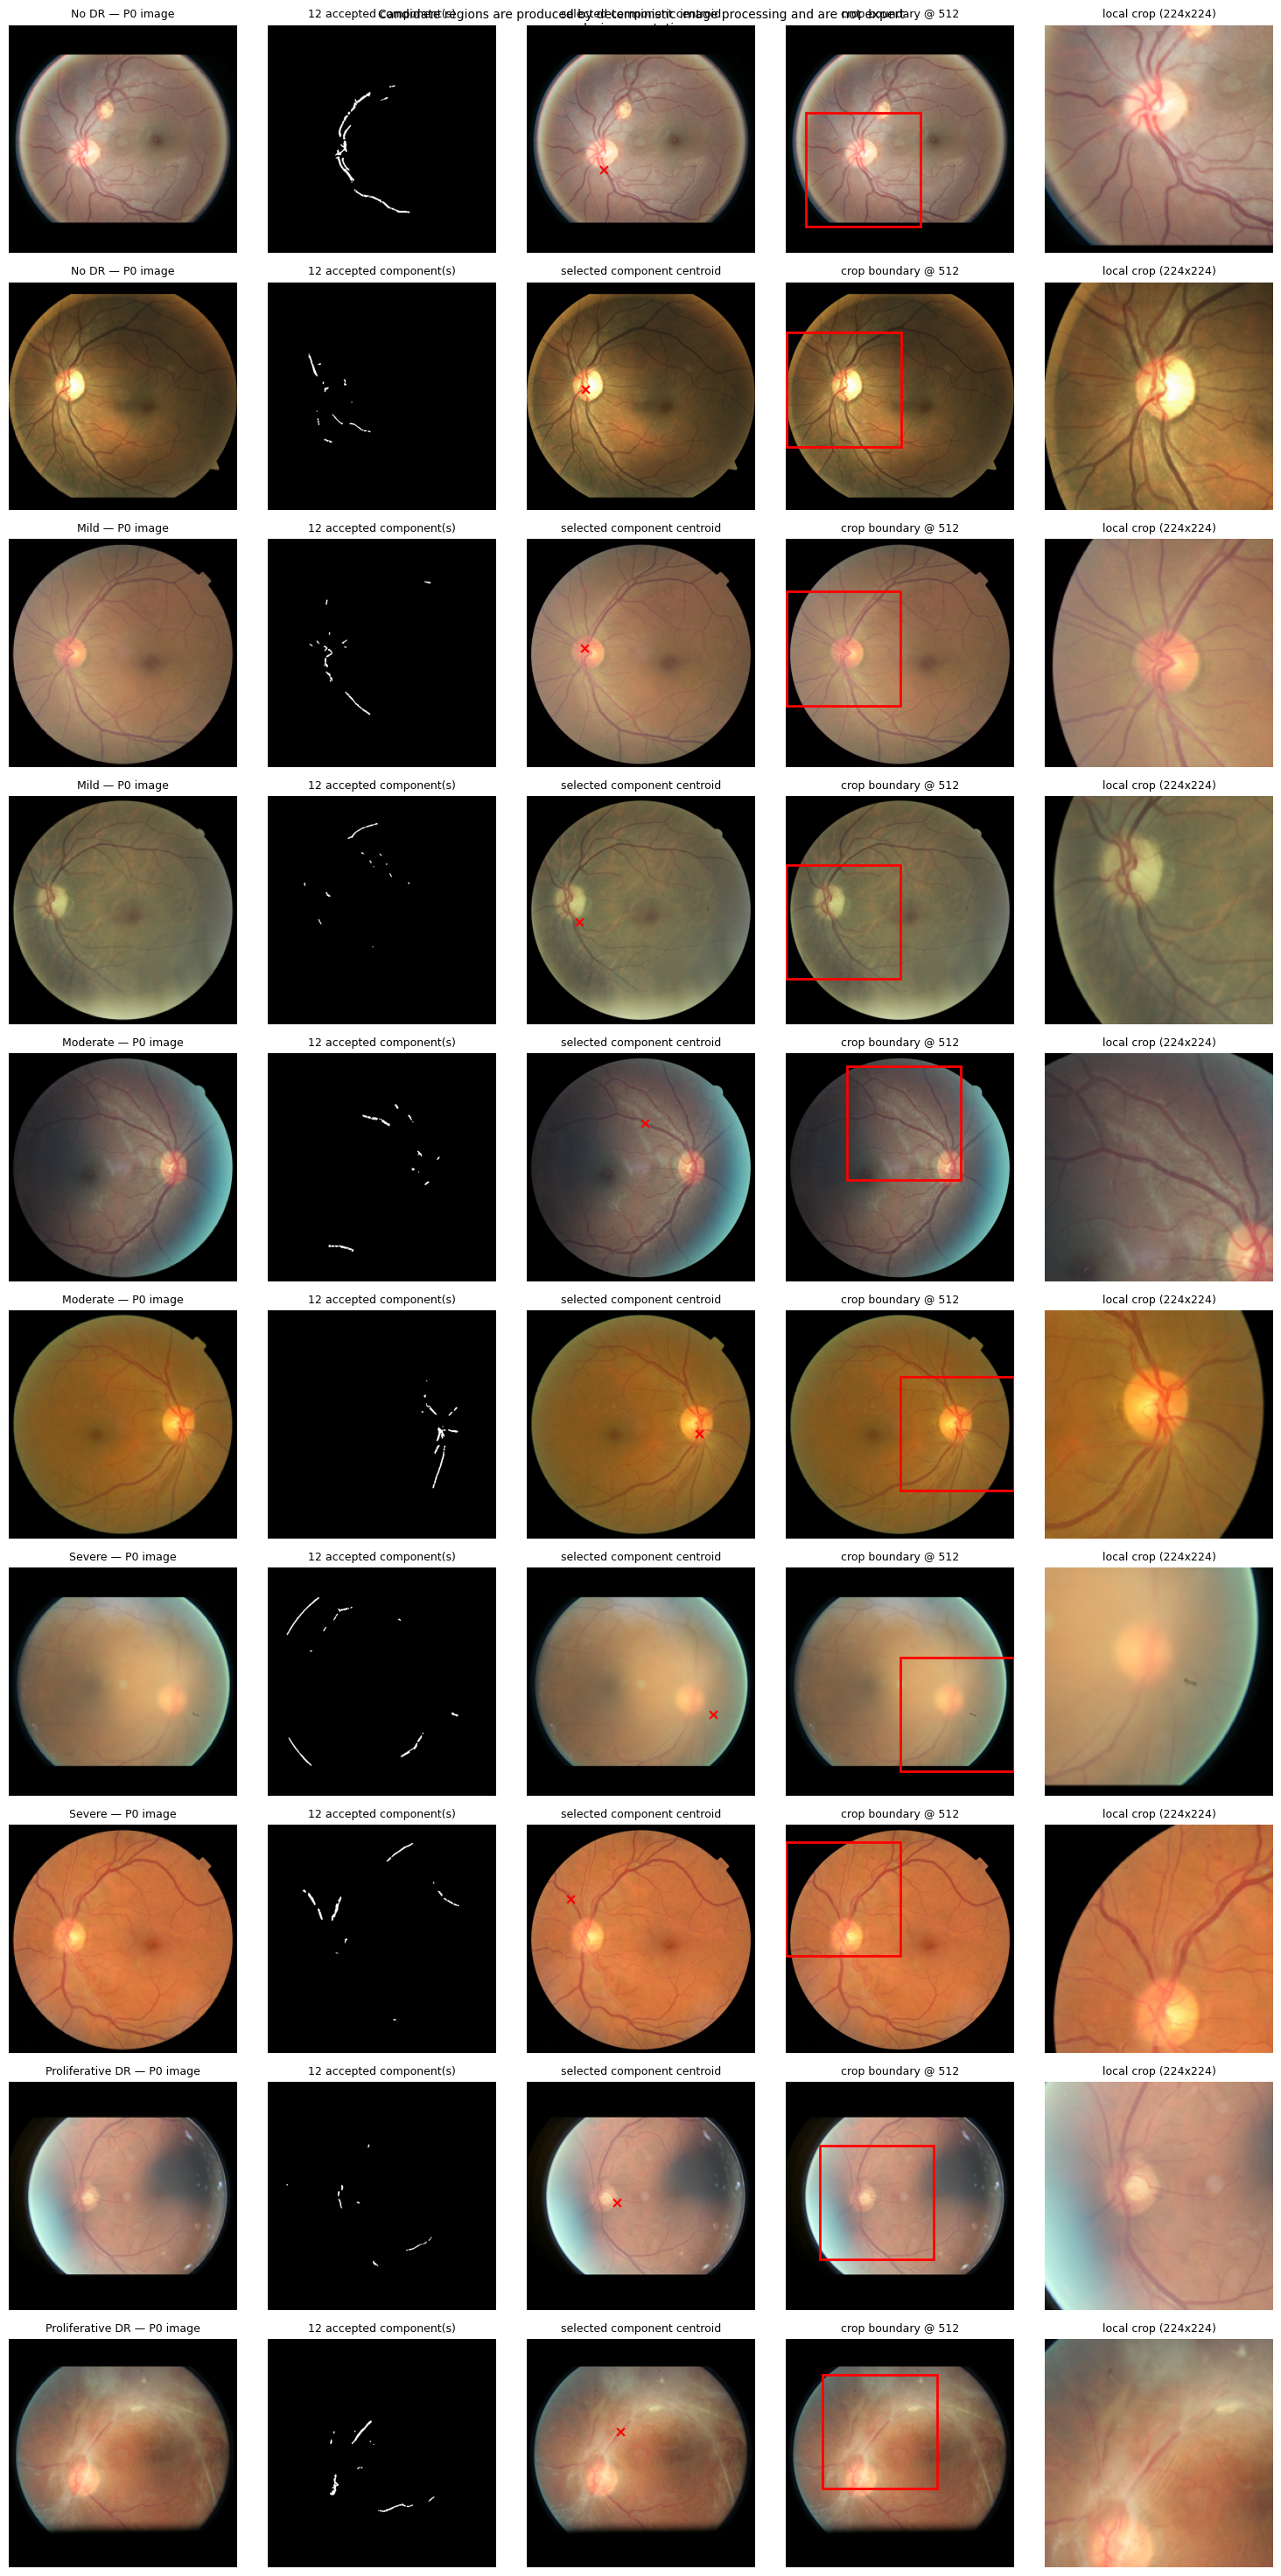

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M11_global_local_crop_fusion/crop_examples.png


In [10]:
examples_per_grade = 2
example_rows = []
for grade in range(NUM_CLASSES):
    grade_rows = train_df[train_df["level"] == grade].sample(
        n=min(examples_per_grade, (train_df["level"] == grade).sum()), random_state=SEED
    )
    example_rows.append(grade_rows)
example_df = pd.concat(example_rows, ignore_index=True)

fig, axes = plt.subplots(len(example_df), 5, figsize=(15, 3 * len(example_df)))

for row_idx, (_, row) in enumerate(example_df.iterrows()):
    image_full = preprocess_p0_full(row["filepath"])
    crop_data = select_local_crop(image_full)

    display_image = cv2.resize(image_full, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)
    local_crop_224 = cv2.resize(
        crop_data["crop_512"], (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA
    )

    axes[row_idx, 0].imshow(display_image)
    axes[row_idx, 0].set_title(f"{CLASS_NAMES[row['level']]} — P0 image", fontsize=9)

    axes[row_idx, 1].imshow(crop_data["accepted_component_mask_512"], cmap="gray")
    axes[row_idx, 1].set_title(
        f"{crop_data['num_candidate_components']} accepted component(s)", fontsize=9
    )

    axes[row_idx, 2].imshow(crop_data["detection_image"])
    if not crop_data["fallback_used"]:
        axes[row_idx, 2].scatter(
            [crop_data["selected_component_centroid_x"]],
            [crop_data["selected_component_centroid_y"]],
            c="red", s=40, marker="x",
        )
    axes[row_idx, 2].set_title(
        "selected component centroid" + (" (fallback: centre)" if crop_data["fallback_used"] else ""),
        fontsize=9,
    )

    axes[row_idx, 3].imshow(crop_data["detection_image"])
    rect = patches.Rectangle(
        (crop_data["crop_x1"], crop_data["crop_y1"]),
        LOCAL_CROP_SIZE, LOCAL_CROP_SIZE,
        linewidth=2, edgecolor="red", facecolor="none",
    )
    axes[row_idx, 3].add_patch(rect)
    axes[row_idx, 3].set_title("crop boundary @ 512", fontsize=9)

    axes[row_idx, 4].imshow(local_crop_224)
    axes[row_idx, 4].set_title("local crop (224x224)", fontsize=9)

    for col in range(5):
        axes[row_idx, col].axis("off")

fig.suptitle(
    "Candidate regions are produced by deterministic image processing and are not expert\n"
    "lesion annotations.",
    fontsize=10,
)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "crop_examples.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIGURE_DIR / 'crop_examples.png'}")

## 12. Dataset class, paired global-local augmentation, and crop caching

The global and local views must receive **exactly the same** sampled horizontal flip,
rotation, translation, scale, and colour jitter — otherwise M11 would be training on two
independently-augmented, unrelated images rather than two views of the same underlying scene.
`paired_train_transform()` samples one set of parameters via TorchVision's own
`RandomAffine.get_params()` and `ColorJitter`, and applies the identical values to both views
— **bilinear** interpolation for both, since both are ordinary RGB images (unlike M09's boxes
or M10's soft mask, there is no "this one must be nearest-neighbour" case here at all).

**Crop-metadata caching**: only the deterministic *crop coordinates and component metadata*
are cached (not the pixel crop itself) — recomputing detection is the expensive part, so
caching the metadata avoids recomputing it every epoch, while the actual crop pixels are
still read fresh from the source image on every access (cheap) using the cached coordinates.
The cache is deterministic and contains no label-dependent information. Since the cache key
is derived from `Path(image_name).stem`, two different images that happened to share the
same filename stem (e.g. from different source directories) would silently overwrite one
another's cache entries — a uniqueness check across the combined train+val image names runs
before the cache is built, to catch that case explicitly rather than let it fail silently.

In [11]:
CROP_PARAM_KEY = (
    f"det{DETECTION_SIZE}_clahe{CLAHE_CLIP_LIMIT}_bg{BACKGROUND_SIGMA}_"
    f"pct{DARK_RESPONSE_PERCENTILE}_area{MIN_COMPONENT_AREA}-{MAX_COMPONENT_AREA}_"
    f"ar{MAX_ASPECT_RATIO}_comp{MAX_CANDIDATE_COMPONENTS}_crop{LOCAL_CROP_SIZE}"
)
CROP_METADATA_CACHE_DIR = CROP_CACHE_DIR / CROP_PARAM_KEY
CROP_METADATA_CACHE_DIR.mkdir(parents=True, exist_ok=True)

CROP_METADATA_FIELDS = [
    "num_candidate_components", "selected_component_rank", "selected_component_area",
    "selected_component_score", "selected_component_centroid_x", "selected_component_centroid_y",
    "crop_x1", "crop_y1", "crop_x2", "crop_y2", "fallback_used",
]


def _crop_cache_path_for(image_name: str) -> Path:
    return CROP_METADATA_CACHE_DIR / f"{Path(image_name).stem}.json"


def _crop_metadata_only(crop_data: dict) -> dict:
    return {key: crop_data[key] for key in CROP_METADATA_FIELDS}


def build_crop_cache(dataframe: pd.DataFrame) -> None:
    """Compute and cache crop metadata (coordinates, not pixels) for every image in
    dataframe that isn't already cached. Deterministic, no label-dependent information,
    safe to re-run."""
    missing = [
        row for _, row in dataframe.iterrows()
        if not _crop_cache_path_for(row["image"]).exists()
    ]
    if not missing:
        print(f"Crop-metadata cache already complete for {len(dataframe):,} images.")
        return

    for row in tqdm(missing, desc=f"caching crop metadata ({CROP_METADATA_CACHE_DIR.name})"):
        image_full = preprocess_p0_full(row["filepath"])
        crop_data = select_local_crop(image_full)
        with open(_crop_cache_path_for(row["image"]), "w") as f:
            json.dump(_crop_metadata_only(crop_data), f)

    print(f"Cached {len(missing):,} new crop-metadata entries -> {CROP_METADATA_CACHE_DIR}")


def get_crop_metadata(row) -> dict:
    cache_path = _crop_cache_path_for(row["image"])
    if cache_path.exists():
        with open(cache_path) as f:
            return json.load(f)
    image_full = preprocess_p0_full(row["filepath"])
    crop_data = select_local_crop(image_full)
    metadata = _crop_metadata_only(crop_data)
    with open(cache_path, "w") as f:
        json.dump(metadata, f)
    return metadata


all_image_names = pd.concat(
    [
        train_df["image"],
        val_df["image"],
    ],
    ignore_index=True,
)

all_cache_stems = all_image_names.map(
    lambda image_name: Path(str(image_name)).stem
)

if not all_cache_stems.is_unique:
    duplicate_stems = all_cache_stems[
        all_cache_stems.duplicated(keep=False)
    ].unique()

    raise RuntimeError(
        "Duplicate image stems would overwrite M11 crop-cache files: "
        f"{duplicate_stems[:10].tolist()}"
    )

print("Crop-cache image-stem uniqueness check: PASSED")

build_crop_cache(train_df)
build_crop_cache(val_df)

Crop-cache image-stem uniqueness check: PASSED
Crop-metadata cache already complete for 24,586 images.
Crop-metadata cache already complete for 5,270 images.


In [12]:
colour_jitter = transforms.ColorJitter(
    brightness=BRIGHTNESS_JITTER,
    contrast=CONTRAST_JITTER,
    saturation=SATURATION_JITTER,
    hue=HUE_JITTER,
)


def paired_train_transform(global_image: Image.Image, local_image: Image.Image):
    if torch.rand(1).item() < HORIZONTAL_FLIP_PROBABILITY:
        global_image = TF.hflip(global_image)
        local_image = TF.hflip(local_image)

    angle, translate, scale, shear = transforms.RandomAffine.get_params(
        degrees=[-ROTATION_DEGREES, ROTATION_DEGREES],
        translate=[TRANSLATE_FRACTION, TRANSLATE_FRACTION],
        scale_ranges=[SCALE_MIN, SCALE_MAX],
        shears=None,
        img_size=[IMAGE_SIZE, IMAGE_SIZE],
    )

    global_image = TF.affine(
        global_image, angle=angle, translate=translate, scale=scale, shear=shear,
        interpolation=transforms.InterpolationMode.BILINEAR, fill=0,
    )
    local_image = TF.affine(
        local_image, angle=angle, translate=translate, scale=scale, shear=shear,
        interpolation=transforms.InterpolationMode.BILINEAR, fill=0,
    )

    # Same colour-jitter sampled values applied to both views.
    jitter_params = transforms.ColorJitter.get_params(
        colour_jitter.brightness, colour_jitter.contrast,
        colour_jitter.saturation, colour_jitter.hue,
    )
    fn_idx, brightness_factor, contrast_factor, saturation_factor, hue_factor = jitter_params
    for image_ref in ("global_image", "local_image"):
        img = global_image if image_ref == "global_image" else local_image
        for fn_id in fn_idx:
            if fn_id == 0 and brightness_factor is not None:
                img = TF.adjust_brightness(img, brightness_factor)
            elif fn_id == 1 and contrast_factor is not None:
                img = TF.adjust_contrast(img, contrast_factor)
            elif fn_id == 2 and saturation_factor is not None:
                img = TF.adjust_saturation(img, saturation_factor)
            elif fn_id == 3 and hue_factor is not None:
                img = TF.adjust_hue(img, hue_factor)
        if image_ref == "global_image":
            global_image = img
        else:
            local_image = img

    global_tensor = TF.normalize(TF.to_tensor(global_image), mean=list(VIT_MEAN), std=list(VIT_STD))
    local_tensor = TF.normalize(TF.to_tensor(local_image), mean=list(VIT_MEAN), std=list(VIT_STD))

    return global_tensor, local_tensor


def paired_eval_transform(global_image: Image.Image, local_image: Image.Image):
    global_tensor = TF.normalize(TF.to_tensor(global_image), mean=list(VIT_MEAN), std=list(VIT_STD))
    local_tensor = TF.normalize(TF.to_tensor(local_image), mean=list(VIT_MEAN), std=list(VIT_STD))
    return global_tensor, local_tensor


class GlobalLocalDRDataset(Dataset):
    """Returns global_image, local_image, label, and identifying/crop metadata. Crop
    selection never sees the label - only the cached coordinates (image-derived) are used
    to slice out the local crop from a freshly-loaded image at __getitem__ time."""

    def __init__(self, dataframe: pd.DataFrame, train_mode: bool = False):
        self.df = dataframe.reset_index(drop=True)
        self.train_mode = train_mode

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, index: int):
        row = self.df.iloc[index]

        image_full = preprocess_p0_full(row["filepath"])
        global_224 = cv2.resize(image_full, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)

        crop_metadata = get_crop_metadata(row)
        detection_image = cv2.resize(
            image_full, (DETECTION_SIZE, DETECTION_SIZE), interpolation=cv2.INTER_AREA
        )
        local_512 = detection_image[
            crop_metadata["crop_y1"]:crop_metadata["crop_y2"],
            crop_metadata["crop_x1"]:crop_metadata["crop_x2"],
        ]
        local_224 = cv2.resize(local_512, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)

        global_image = Image.fromarray(global_224)
        local_image = Image.fromarray(local_224)

        if self.train_mode:
            global_tensor, local_tensor = paired_train_transform(global_image, local_image)
        else:
            global_tensor, local_tensor = paired_eval_transform(global_image, local_image)

        assert global_tensor.shape == (3, IMAGE_SIZE, IMAGE_SIZE)
        assert local_tensor.shape == (3, IMAGE_SIZE, IMAGE_SIZE)
        assert torch.isfinite(global_tensor).all()
        assert torch.isfinite(local_tensor).all()

        label = int(row["level"])
        assert 0 <= label <= 4

        return {
            "global_image": global_tensor,
            "local_image": local_tensor,
            "label": label,
            "image": row["image"],
            "patient_id": row["patient_id"],
            "eye": row["eye"],
            "index": index,
            "crop_metadata": crop_metadata,
        }


def collate_global_local(batch):
    return {
        "global_image": torch.stack([item["global_image"] for item in batch]),
        "local_image": torch.stack([item["local_image"] for item in batch]),
        "label": torch.tensor([item["label"] for item in batch], dtype=torch.long),
        "image": [item["image"] for item in batch],
        "patient_id": [item["patient_id"] for item in batch],
        "eye": [item["eye"] for item in batch],
        "index": torch.tensor([item["index"] for item in batch], dtype=torch.long),
        "crop_metadata": [item["crop_metadata"] for item in batch],
    }


train_ds = GlobalLocalDRDataset(train_df, train_mode=True)
val_ds = GlobalLocalDRDataset(val_df, train_mode=False)

print(f"train_ds: {len(train_ds):,} | val_ds: {len(val_ds):,}")

train_ds: 24,586 | val_ds: 5,270


## 13. DataLoaders

Ordinary shuffling, no `WeightedRandomSampler` — identical to M07. Uses `PHYSICAL_BATCH_SIZE`
(16), not the effective batch size — gradient accumulation (Section 17) recovers M07's
effective batch of 32. A custom `collate_fn` is needed because each example carries
non-tensor metadata (image name, crop metadata dict) alongside the two image tensors.

In [13]:
train_loader = DataLoader(
    train_ds,
    batch_size=PHYSICAL_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    worker_init_fn=seed_worker,
    collate_fn=collate_global_local,
)

val_loader = DataLoader(
    val_ds,
    batch_size=PHYSICAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    worker_init_fn=seed_worker,
    collate_fn=collate_global_local,
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print(f"Physical batch: {PHYSICAL_BATCH_SIZE}  Accumulation: {GRAD_ACCUMULATION_STEPS}  "
      f"Effective batch: {EFFECTIVE_BATCH_SIZE}")

Train batches: 1537 | Val batches: 330
Physical batch: 16  Accumulation: 2  Effective batch: 32


## 14. Class weights and ordinal-aware loss

Exactly M07's loss, unmodified: clipped class-weighted cross-entropy plus a normalised
expected squared grade-distance penalty (weight 0.5).

In [14]:
class OrdinalPenalisedLoss(nn.Module):
    """Clipped weighted CE plus normalised expected squared grade distance (unchanged from M07)."""

    def __init__(
        self,
        num_classes: int = NUM_CLASSES,
        ordinal_weight: float = ORDINAL_PENALTY_WEIGHT,
        class_weights: torch.Tensor = None,
        label_smoothing: float = 0.0,
    ):
        super().__init__()
        self.ordinal_weight = ordinal_weight
        self.num_classes = num_classes
        self.max_squared_distance = float((num_classes - 1) ** 2)

        self.cross_entropy = nn.CrossEntropyLoss(
            weight=class_weights, label_smoothing=label_smoothing,
        )
        self.register_buffer("grade_values", torch.arange(num_classes, dtype=torch.float32))

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = self.cross_entropy(logits, targets)

        probabilities = F.softmax(logits, dim=1)
        target_grades = targets.to(dtype=probabilities.dtype).unsqueeze(1)
        squared_distances = (self.grade_values.unsqueeze(0) - target_grades).pow(2)
        normalised_distances = squared_distances / self.max_squared_distance
        ordinal_loss = (probabilities * normalised_distances).sum(dim=1).mean()

        return ce_loss + self.ordinal_weight * ordinal_loss


raw_weights = compute_class_weight(
    class_weight=CLASS_WEIGHT_METHOD,
    classes=np.arange(NUM_CLASSES),
    y=train_df["level"].to_numpy(),
)
clipped_weights = np.clip(raw_weights, CLASS_WEIGHT_CLIP_MIN, CLASS_WEIGHT_CLIP_MAX)
class_weights = torch.tensor(clipped_weights, dtype=torch.float32, device=device)

criterion = OrdinalPenalisedLoss(
    num_classes=NUM_CLASSES,
    ordinal_weight=ORDINAL_PENALTY_WEIGHT,
    class_weights=class_weights,
    label_smoothing=LABEL_SMOOTHING,
).to(device)
LOSS_FUNCTION_LABEL = "clipped_weighted_ce_plus_normalised_expected_squared_ordinal_penalty"

print("Loss: clipped weighted CE + 0.5 x normalised ordinal penalty (unchanged from M07)")
print("Raw balanced weights:", np.round(raw_weights, 3))
print("Clipped weights:", np.round(clipped_weights, 3))

Loss: clipped weighted CE + 0.5 x normalised ordinal penalty (unchanged from M07)
Raw balanced weights: [0.272 2.877 1.33  8.061 9.699]
Clipped weights: [0.5  2.5  1.33 2.5  2.5 ]


## 15. Shared-backbone global-local fusion model

**One shared MaxViT backbone, not two independent backbones** — both views are concatenated
along the batch dimension, pushed through the backbone in a single forward call, then split
back apart and their pooled features concatenated before the final linear classifier. This
keeps the parameter increase small (only the classifier's input width doubles; the backbone
itself is not duplicated), keeps global and local features in the same learned
representation space, and keeps M11's comparison against M07 less confounded by a large,
unrelated capacity increase than two-backbone designs would introduce. No hidden fusion
network, attention gate, or learned weighting is added — feature concatenation followed by
one `nn.Linear` only, as specified.

The dummy forward test below runs in `eval()` mode for the same BatchNorm-safety reason as
M09/M10: MaxViT's MBConv blocks contain real BatchNorm layers, and this shape test uses
all-zero dummy images that would otherwise contaminate the real model's running statistics
before any genuine training happens.

In [15]:
class GlobalLocalMaxViT(nn.Module):
    def __init__(
        self,
        model_name: str,
        num_classes: int,
        pretrained: bool = True,
    ):
        super().__init__()

        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0,
            global_pool="avg",
        )

        feature_dim = self.backbone.num_features
        self.classifier = nn.Linear(feature_dim * 2, num_classes)

    def forward(
        self,
        global_image: torch.Tensor,
        local_image: torch.Tensor,
    ) -> torch.Tensor:
        batch_size = global_image.shape[0]

        combined = torch.cat(
            [global_image, local_image],
            dim=0,
        )
        combined_features = self.backbone(combined)

        if not torch.isfinite(combined_features).all():
            raise RuntimeError("Non-finite features detected.")

        global_features, local_features = combined_features.chunk(2, dim=0)

        assert global_features.shape[0] == batch_size
        assert local_features.shape[0] == batch_size

        fused_features = torch.cat(
            [global_features, local_features],
            dim=1,
        )

        logits = self.classifier(fused_features)

        if not torch.isfinite(logits).all():
            raise RuntimeError("Non-finite classifier logits detected.")

        return logits


def build_model(pretrained: bool = True) -> GlobalLocalMaxViT:
    return GlobalLocalMaxViT(
        model_name=MODEL_NAME,
        num_classes=NUM_CLASSES,
        pretrained=pretrained,
    ).to(device)


model = build_model(pretrained=True)
total_parameters = sum(p.numel() for p in model.parameters())

print(f"Model: {MODEL_NAME}  (shared backbone, two views, feature concatenation)")
print(f"Total parameters: {total_parameters:,}")

previous_training_mode = model.training
model.eval()

try:
    with torch.no_grad():
        dummy_global = torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
        dummy_local = torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
        output = model(dummy_global, dummy_local)
finally:
    model.train(previous_training_mode)

assert output.shape == (2, NUM_CLASSES)
print("Global-local dummy forward test: PASSED")

Model: maxvit_tiny_tf_224.in1k  (shared backbone, two views, feature concatenation)
Total parameters: 30,408,653
Global-local dummy forward test: PASSED


## 16. Optimiser and scheduler

Exactly M07's recipe: `AdamW`, 3-epoch linear warm-up, cosine decay after. The scheduler
steps once per **epoch** (as in M07), not once per mini-batch and not once per optimiser
step under accumulation — gradient accumulation changes how often `optimizer.step()` is
called within an epoch, but the learning-rate schedule itself remains epoch-based, matching
M07 exactly.

In [16]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

warmup_scheduler = LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS,
)
cosine_scheduler = CosineAnnealingLR(
    optimizer, T_max=max(1, MAX_EPOCHS - WARMUP_EPOCHS),
)
scheduler = SequentialLR(
    optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[WARMUP_EPOCHS],
)

SCHEDULER_CONFIG = {
    "name": "SequentialLR",
    "warmup_scheduler": "LinearLR",
    "warmup_start_factor": 0.1,
    "warmup_end_factor": 1.0,
    "warmup_epochs": WARMUP_EPOCHS,
    "main_scheduler": "CosineAnnealingLR",
}

print(f"Optimizer: AdamW(lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler: {WARMUP_EPOCHS}-epoch linear warm-up -> CosineAnnealingLR (stepped per epoch)")

Optimizer: AdamW(lr=5e-05, weight_decay=0.05)
Scheduler: 3-epoch linear warm-up -> CosineAnnealingLR (stepped per epoch)


## 17. Training and validation functions

Implements gradient accumulation to recover M07's effective batch size of 32 from a physical
batch of 16: the loss is divided by the number of mini-batches actually in the *current*
accumulation group before `backward()` — not always `GRAD_ACCUMULATION_STEPS`, since the
final group in an epoch is incomplete whenever `len(train_loader)` isn't evenly divisible by
`GRAD_ACCUMULATION_STEPS`, and dividing a lone final mini-batch's loss by 2 would silently
halve its effective gradient contribution. An optimiser step happens only at accumulation
boundaries, gradients are unscaled before clipping (required for correct clipping under AMP),
and clipping happens immediately before the optimiser step — not before every mini-batch's
backward call. Finite-value checks are placed at every stage the spec calls for: inputs,
fused features (inside the model itself, Section 15), logits (both inside the model and
after the loss is computed), loss, and gradients (just before the optimiser step); metrics
are checked after the epoch via the existing QWK/MAE-finiteness guards.

In [17]:
use_amp = device.type == "cuda"

# A lower initial AMP scale is used because the first M11 attempt produced
# non-finite gradients. This affects numerical scaling only, not the model design.
scaler = torch.amp.GradScaler(
    "cuda",
    enabled=use_amp,
    init_scale=1024.0,
)


def run_epoch(
    model: nn.Module,
    loader,
    optimizer=None,
    train_mode: bool = True,
    grad_clip: float = GRAD_CLIP,
    accumulation_steps: int = GRAD_ACCUMULATION_STEPS,
):
    if train_mode and optimizer is None:
        raise ValueError("An optimizer must be supplied during training.")

    if accumulation_steps < 1:
        raise ValueError("accumulation_steps must be at least 1.")

    if train_mode:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_samples = 0

    all_labels = []
    all_preds = []
    all_probs = []
    all_logits = []
    all_indices = []

    skipped_optimizer_steps = 0
    description = "train" if train_mode else "eval"

    if train_mode:
        optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(
        tqdm(loader, leave=False, desc=description)
    ):
        global_images = batch["global_image"].to(
            device,
            non_blocking=True,
        )
        local_images = batch["local_image"].to(
            device,
            non_blocking=True,
        )
        labels = batch["label"].to(
            device,
            non_blocking=True,
        )

        if not torch.isfinite(global_images).all():
            raise RuntimeError("Non-finite global input images detected.")

        if not torch.isfinite(local_images).all():
            raise RuntimeError("Non-finite local input images detected.")

        with torch.set_grad_enabled(train_mode):
            with torch.autocast(
                device_type=device.type,
                enabled=use_amp,
            ):
                logits = model(
                    global_images,
                    local_images,
                )

                if not torch.isfinite(logits).all():
                    raise RuntimeError("Non-finite logits detected.")

                loss = criterion(logits, labels)

                if not torch.isfinite(loss):
                    raise RuntimeError("Non-finite loss detected.")

        if train_mode:
            # The final accumulation group may contain fewer mini-batches
            # than accumulation_steps, so divide by its actual size.
            group_start = (
                step // accumulation_steps
            ) * accumulation_steps

            steps_in_current_group = min(
                accumulation_steps,
                len(loader) - group_start,
            )

            scaled_loss = loss / steps_in_current_group
            scaler.scale(scaled_loss).backward()

            is_accumulation_boundary = (
                ((step + 1) % accumulation_steps == 0)
                or ((step + 1) == len(loader))
            )

            if is_accumulation_boundary:
                # Convert gradients back to their true scale.
                # GradScaler also records whether Inf/NaN values occurred.
                scaler.unscale_(optimizer)

                has_nonfinite_gradient = any(
                    param.grad is not None
                    and not torch.isfinite(param.grad).all()
                    for param in model.parameters()
                )

                if has_nonfinite_gradient:
                    if not use_amp:
                        optimizer.zero_grad(set_to_none=True)
                        raise RuntimeError(
                            "Non-finite gradients detected without AMP."
                        )

                    previous_scale = scaler.get_scale()

                    # Because unscale_ recorded the non-finite gradients,
                    # GradScaler will skip this optimiser update safely.
                    scaler.step(optimizer)
                    scaler.update()

                    skipped_optimizer_steps += 1

                    print(
                        "\nAMP skipped an optimiser step because of "
                        "non-finite gradients. "
                        f"Scale: {previous_scale:.0f} "
                        f"-> {scaler.get_scale():.0f}"
                    )

                else:
                    if grad_clip > 0:
                        grad_norm = nn.utils.clip_grad_norm_(
                            model.parameters(),
                            max_norm=grad_clip,
                            error_if_nonfinite=False,
                        )

                        if not bool(torch.isfinite(grad_norm).item()):
                            optimizer.zero_grad(set_to_none=True)
                            raise RuntimeError(
                                "Gradient norm became non-finite "
                                "despite finite individual gradients."
                            )

                    scaler.step(optimizer)
                    scaler.update()

                optimizer.zero_grad(set_to_none=True)

        probabilities = F.softmax(
            logits.detach(),
            dim=1,
        )

        if not torch.isfinite(probabilities).all():
            raise RuntimeError(
                "Non-finite prediction probabilities detected."
            )

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        all_preds.extend(
            probabilities.argmax(dim=1).cpu().tolist()
        )
        all_labels.extend(
            labels.detach().cpu().tolist()
        )
        all_probs.extend(
            probabilities.cpu().tolist()
        )
        all_logits.extend(
            logits.detach().cpu().tolist()
        )
        all_indices.extend(
            batch["index"].cpu().tolist()
        )

    if total_samples == 0:
        raise RuntimeError(
            "The DataLoader produced no samples."
        )

    epoch_qwk = cohen_kappa_score(
        all_labels,
        all_preds,
        weights="quadratic",
    )

    if not np.isfinite(epoch_qwk):
        raise RuntimeError(
            "QWK became NaN or infinity during the epoch."
        )

    epoch_mae = float(
        np.mean(
            np.abs(
                np.asarray(all_preds)
                - np.asarray(all_labels)
            )
        )
    )

    if not np.isfinite(epoch_mae):
        raise RuntimeError(
            "MAE became NaN or infinity during the epoch."
        )

    if train_mode and skipped_optimizer_steps > 0:
        print(
            f"AMP skipped {skipped_optimizer_steps} "
            "optimiser step(s) during this epoch."
        )

    return {
        "loss": total_loss / total_samples,
        "accuracy": accuracy_score(
            all_labels,
            all_preds,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            all_labels,
            all_preds,
        ),
        "macro_f1": f1_score(
            all_labels,
            all_preds,
            average="macro",
            zero_division=0,
        ),
        "qwk": epoch_qwk,
        "mae": epoch_mae,
        "labels": all_labels,
        "preds": all_preds,
        "probs": all_probs,
        "logits": all_logits,
        "indices": all_indices,
        "skipped_optimizer_steps": skipped_optimizer_steps,
    }


def checkpoint_improved(
    val_qwk: float,
    val_macro_f1: float,
    best_qwk: float,
    best_macro_f1: float,
    tolerance: float = QWK_TOLERANCE,
) -> bool:
    """Validation QWK primary, validation macro-F1 tie-break."""

    if val_qwk > best_qwk + tolerance:
        return True

    if (
        abs(val_qwk - best_qwk) <= tolerance
        and val_macro_f1 > best_macro_f1
    ):
        return True

    return False

## 18. Early-stopping training loop

Same checkpoint rule and early-stopping structure as M07 (validation QWK primary, macro-F1
tie-break), with `MAE` added to the per-epoch record as requested.

In [18]:
history = []
best_qwk = -1.0
best_macro_f1 = -1.0
patience_left = EARLY_STOPPING_PATIENCE

print("=" * 60)
print(f"  {RUN_NAME}")
print("=" * 60)
print(f"{'Epoch':<8} {'Tr Loss':>10} {'Tr QWK':>8} {'Val Loss':>10} {'Val QWK':>8} {'Val F1':>8} {'Val MAE':>8}")
print("-" * 60)

for epoch in range(1, MAX_EPOCHS + 1):
    lr_used = optimizer.param_groups[0]["lr"]

    train_metrics = run_epoch(model, train_loader, optimizer=optimizer, train_mode=True)
    val_metrics = run_epoch(model, val_loader, train_mode=False)
    scheduler.step()

    epoch_record = {
        "epoch": epoch,
        "learning_rate": lr_used,
        "train_loss": train_metrics["loss"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_qwk": val_metrics["qwk"],
        "val_mae": val_metrics["mae"],
    }
    history.append(epoch_record)
    pd.DataFrame(history).to_csv(LOG_DIR / "training_history.csv", index=False)

    marker = ""
    if checkpoint_improved(val_metrics["qwk"], val_metrics["macro_f1"], best_qwk, best_macro_f1):
        best_qwk = val_metrics["qwk"]
        best_macro_f1 = val_metrics["macro_f1"]
        patience_left = EARLY_STOPPING_PATIENCE
        torch.save(
            {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_balanced_accuracy": val_metrics["balanced_accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_qwk": val_metrics["qwk"],
                "val_mae": val_metrics["mae"],
            },
            BEST_CHECKPOINT_PATH,
        )
        marker = "  [best]"
    else:
        patience_left -= 1

    print(
        f"{epoch:<8} {train_metrics['loss']:>10.4f} {train_metrics['qwk']:>8.4f} "
        f"{val_metrics['loss']:>10.4f} {val_metrics['qwk']:>8.4f} {val_metrics['macro_f1']:>8.4f} "
        f"{val_metrics['mae']:>8.4f}{marker}"
    )

    if patience_left <= 0:
        print(f"Early stopping at epoch {epoch}.")
        break

print(f"\nBest val QWK = {best_qwk:.4f} (macro-F1 = {best_macro_f1:.4f}) -> {BEST_CHECKPOINT_PATH.name}")

  M11_global_local_crop_fusion
Epoch       Tr Loss   Tr QWK   Val Loss  Val QWK   Val F1  Val MAE
------------------------------------------------------------


train:   0%|          | 0/1537 [00:00<?, ?it/s]

eval:   0%|          | 0/330 [00:00<?, ?it/s]

1            1.3818   0.0913     1.2276   0.3652   0.2658   0.4501  [best]


train:   0%|          | 0/1537 [00:00<?, ?it/s]

...

eval:   0%|          | 0/330 [00:00<?, ?it/s]

14           0.1069   0.9603     1.8434   0.7333   0.5361   0.3011


train:   0%|          | 0/1537 [00:00<?, ?it/s]

eval:   0%|          | 0/330 [00:00<?, ?it/s]

15           0.0828   0.9702     2.3052   0.7236   0.5199   0.2922
Early stopping at epoch 15.

Best val QWK = 0.7695 (macro-F1 = 0.5477) -> best.pt


## 19. Training curves

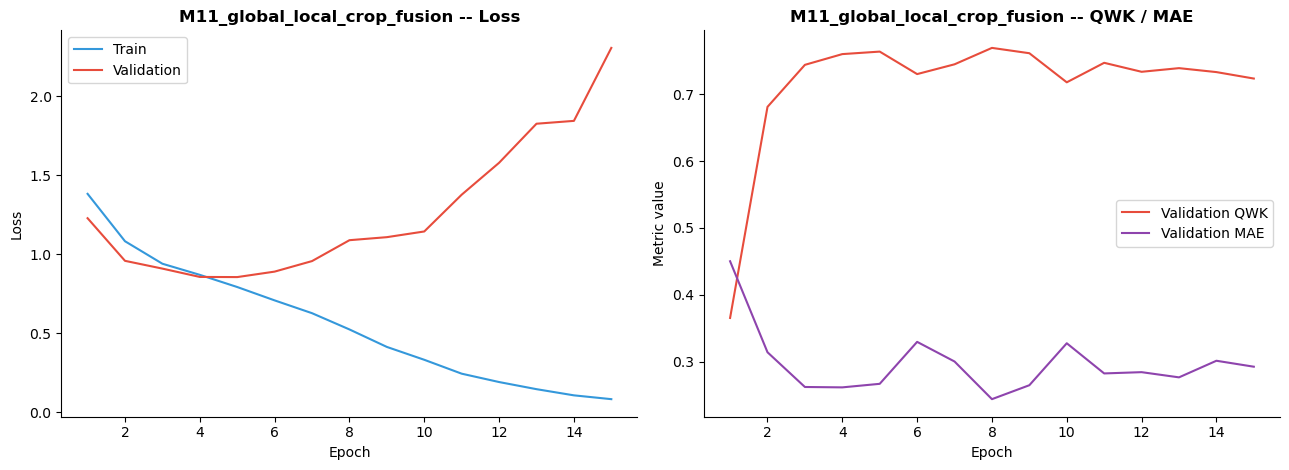

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M11_global_local_crop_fusion/training_curves.png


In [19]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train", color="#3498DB")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation", color="#E74C3C")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title(f"{RUN_NAME} -- Loss", fontweight="bold")
axes[0].legend(); axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(history_df["epoch"], history_df["val_qwk"], label="Validation QWK", color="#E74C3C")
axes[1].plot(history_df["epoch"], history_df["val_mae"], label="Validation MAE", color="#8E44AD")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Metric value")
axes[1].set_title(f"{RUN_NAME} -- QWK / MAE", fontweight="bold")
axes[1].legend(); axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "training_curves.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIGURE_DIR / 'training_curves.png'}")

## 20. Validation metrics and confusion matrix

The best checkpoint (by validation QWK, macro-F1 tie-break) is reloaded fresh and
re-evaluated on `val_loader` — **not the internal test set**.

In [20]:
best_checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location=device, weights_only=False)

eval_model = build_model(pretrained=False)
eval_model.load_state_dict(best_checkpoint["model_state"])

print(f"Loaded: {BEST_CHECKPOINT_PATH.name}")
print(f"epoch={best_checkpoint['epoch']}  val_qwk={best_checkpoint['val_qwk']:.4f}  "
      f"val_macro_f1={best_checkpoint['val_macro_f1']:.4f}")

final_val_metrics = run_epoch(eval_model, val_loader, train_mode=False)

val_macro_precision = precision_score(
    final_val_metrics["labels"], final_val_metrics["preds"], average="macro", zero_division=0,
)
val_macro_recall = recall_score(
    final_val_metrics["labels"], final_val_metrics["preds"], average="macro", zero_division=0,
)
val_weighted_f1 = f1_score(
    final_val_metrics["labels"], final_val_metrics["preds"], average="weighted", zero_division=0,
)

print()
print("=" * 60)
print(f"  {RUN_NAME} -- VALIDATION RESULTS (best checkpoint)")
print("=" * 60)
print(f"  Val QWK               : {final_val_metrics['qwk']:.4f}")
print(f"  Val accuracy           : {final_val_metrics['accuracy']:.4f}")
print(f"  Val balanced accuracy  : {final_val_metrics['balanced_accuracy']:.4f}")
print(f"  Val macro F1           : {final_val_metrics['macro_f1']:.4f}")
print(f"  Val weighted F1        : {val_weighted_f1:.4f}")
print(f"  Val macro precision    : {val_macro_precision:.4f}")
print(f"  Val macro recall       : {val_macro_recall:.4f}")
print(f"  Val MAE                : {final_val_metrics['mae']:.4f}")
print()
print(classification_report(
    final_val_metrics["labels"], final_val_metrics["preds"],
    labels=list(range(NUM_CLASSES)), target_names=CLASS_NAMES, digits=3, zero_division=0,
))

Loaded: best.pt
epoch=8  val_qwk=0.7695  val_macro_f1=0.5477


eval:   0%|          | 0/330 [00:00<?, ?it/s]


  M11_global_local_crop_fusion -- VALIDATION RESULTS (best checkpoint)
  Val QWK               : 0.7695
  Val accuracy           : 0.8258
  Val balanced accuracy  : 0.5165
  Val macro F1           : 0.5477
  Val weighted F1        : 0.8049
  Val macro precision    : 0.5983
  Val macro recall       : 0.5165
  Val MAE                : 0.2436

                  precision    recall  f1-score   support

           No DR      0.875     0.968     0.919      3873
            Mild      0.253     0.114     0.157       368
        Moderate      0.722     0.571     0.638       800
          Severe      0.424     0.331     0.372       127
Proliferative DR      0.718     0.598     0.652       102

        accuracy                          0.826      5270
       macro avg      0.598     0.516     0.548      5270
    weighted avg      0.794     0.826     0.805      5270



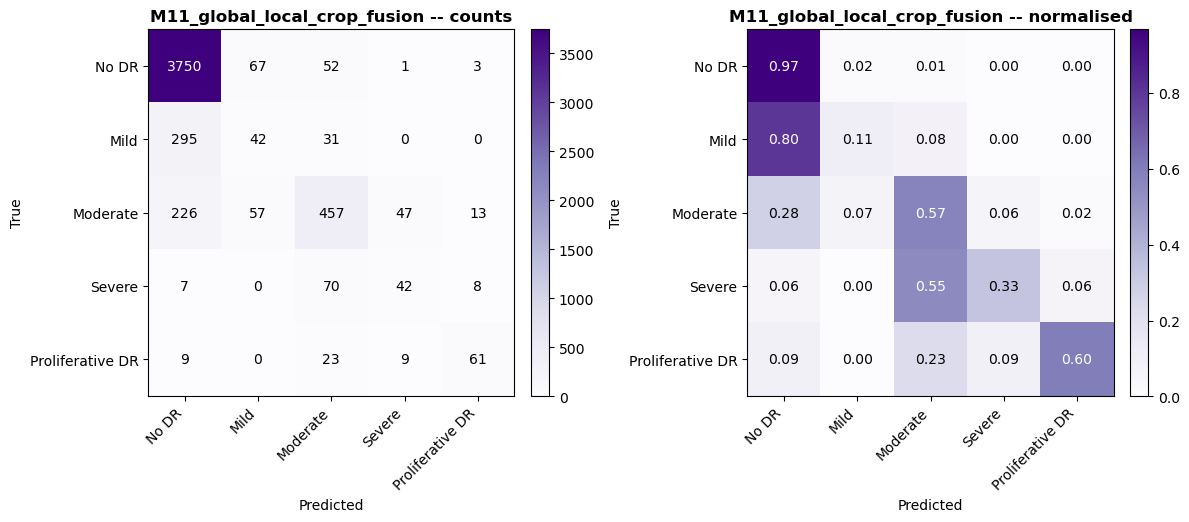

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M11_global_local_crop_fusion/confusion_matrix.png


In [21]:
per_class_precision = precision_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)
per_class_recall = recall_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)
per_class_f1 = f1_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)
per_class_support = np.bincount(final_val_metrics["labels"], minlength=NUM_CLASSES)

cm_counts = confusion_matrix(final_val_metrics["labels"], final_val_metrics["preds"])
cm_normalised = cm_counts.astype(float) / cm_counts.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, data, fmt, title in [
    (axes[0], cm_counts, "d", f"{RUN_NAME} -- counts"),
    (axes[1], cm_normalised, ".2f", f"{RUN_NAME} -- normalised"),
]:
    im = ax.imshow(data, interpolation="nearest", cmap="Purples")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title, fontweight="bold")
    thresh = data.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(data[i, j], fmt), ha="center", va="center",
                     color="white" if data[i, j] > thresh else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "confusion_matrix.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIGURE_DIR / 'confusion_matrix.png'}")

### Targeted error analysis

Beyond the standard metrics, the specific error transitions relevant to clinical severity
progression: Mild→No DR, Mild→Moderate, Moderate→No DR, Severe→Moderate, PDR→Severe, plus
overall under-grading and over-grading rates.

In [22]:
labels_array = np.asarray(final_val_metrics["labels"])
preds_array = np.asarray(final_val_metrics["preds"])
grade_error = preds_array - labels_array
absolute_grade_error = np.abs(grade_error)

mean_absolute_grade_error = float(absolute_grade_error.mean())
within_one_grade_accuracy = float((absolute_grade_error <= 1).mean())
large_grade_error_rate = float((absolute_grade_error > 1).mean())

mild_f1 = float(per_class_f1[1])
moderate_f1 = float(per_class_f1[2])
severe_f1 = float(per_class_f1[3])
pdr_f1 = float(per_class_f1[4])

mild_to_no_dr = int(np.sum((labels_array == 1) & (preds_array == 0)))
mild_to_moderate = int(np.sum((labels_array == 1) & (preds_array == 2)))
moderate_to_no_dr = int(np.sum((labels_array == 2) & (preds_array == 0)))
severe_to_moderate = int(np.sum((labels_array == 3) & (preds_array == 2)))
pdr_to_severe = int(np.sum((labels_array == 4) & (preds_array == 3)))

under_grading_rate = float((grade_error < 0).mean())
over_grading_rate = float((grade_error > 0).mean())

print(f"Mild F1                  : {mild_f1:.4f}")
print(f"Moderate F1              : {moderate_f1:.4f}")
print(f"Severe F1                : {severe_f1:.4f}")
print(f"PDR F1                   : {pdr_f1:.4f}")
print(f"Mean absolute grade error: {mean_absolute_grade_error:.4f}")
print(f"Within-one-grade accuracy: {within_one_grade_accuracy:.4f}")
print(f"Large grade-error rate   : {large_grade_error_rate:.4f}")
print(f"Mild -> No DR errors     : {mild_to_no_dr}")
print(f"Mild -> Moderate errors  : {mild_to_moderate}")
print(f"Moderate -> No DR errors : {moderate_to_no_dr}")
print(f"Severe -> Moderate errors: {severe_to_moderate}")
print(f"PDR -> Severe errors     : {pdr_to_severe}")
print(f"Under-grading rate       : {under_grading_rate:.4f}")
print(f"Over-grading rate        : {over_grading_rate:.4f}")

Mild F1                  : 0.1573
Moderate F1              : 0.6378
Severe F1                : 0.3717
PDR F1                   : 0.6524
Mean absolute grade error: 0.2436
Within-one-grade accuracy: 0.9366
Large grade-error rate   : 0.0634
Mild -> No DR errors     : 295
Mild -> Moderate errors  : 31
Moderate -> No DR errors : 226
Severe -> Moderate errors: 70
PDR -> Severe errors     : 9
Under-grading rate       : 0.1321
Over-grading rate        : 0.0421


## 21. Direct comparison with M07 (official)

Loads M07's **saved JSON results**, not its checkpoint. **M07 is the official comparison for
M11.** M09 and M10 comparisons below are purely descriptive and never influence M11's
training in any way.

                Metric        M07        M11  Difference
                   QWK   0.761905   0.769480    0.007575
              Macro-F1   0.551890   0.547666   -0.004224
     Balanced accuracy   0.550665   0.516474   -0.034191
              Accuracy   0.803416   0.825806    0.022391
               Mild F1   0.123333   0.157303    0.033970
           Moderate F1   0.575603   0.637823    0.062220
             Severe F1   0.489796   0.371681   -0.118115
                PDR F1   0.663317   0.652406   -0.010910
                   MAE   0.270588   0.243643   -0.026945
Large-grade error rate   0.069639   0.063378   -0.006262
         Mild -> No DR 306.000000 295.000000  -11.000000


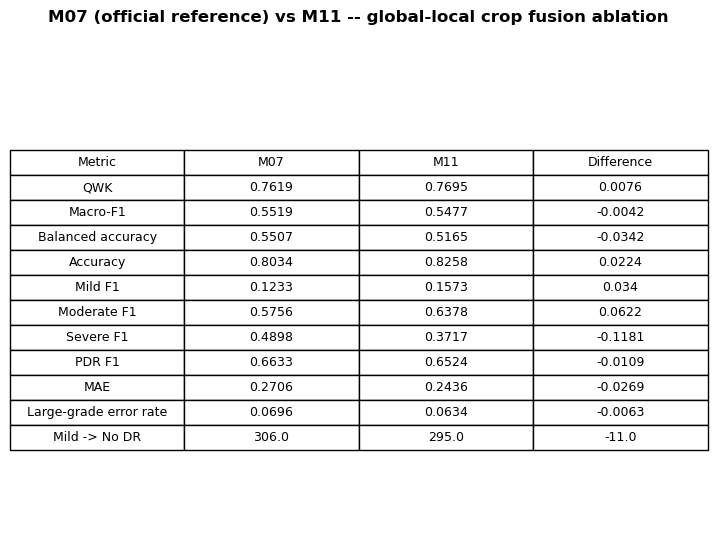

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M11_global_local_crop_fusion/m07_m11_comparison.png


In [23]:
with open(M07_LOG_DIR / "best_metrics.json") as f:
    m07_best_metrics = json.load(f)
with open(M07_LOG_DIR / "validation_metrics.json") as f:
    m07_validation_metrics = json.load(f)

m07_moderate_f1 = float(m07_validation_metrics["per_class_f1"][2])
m07_severe_f1 = float(m07_validation_metrics["per_class_f1"][3])
m07_pdr_f1 = float(m07_validation_metrics["per_class_f1"][4])

comparison_rows = [
    ("QWK", m07_best_metrics["val_qwk"], final_val_metrics["qwk"]),
    ("Macro-F1", m07_best_metrics["val_macro_f1"], final_val_metrics["macro_f1"]),
    ("Balanced accuracy", m07_best_metrics["val_balanced_accuracy"], final_val_metrics["balanced_accuracy"]),
    ("Accuracy", m07_best_metrics["val_accuracy"], final_val_metrics["accuracy"]),
    ("Mild F1", m07_validation_metrics["mild_f1"], mild_f1),
    ("Moderate F1", m07_moderate_f1, moderate_f1),
    ("Severe F1", m07_severe_f1, severe_f1),
    ("PDR F1", m07_pdr_f1, pdr_f1),
    ("MAE", m07_validation_metrics["mean_absolute_grade_error"], mean_absolute_grade_error),
    ("Large-grade error rate", m07_validation_metrics["large_grade_error_rate"], large_grade_error_rate),
    ("Mild -> No DR", m07_validation_metrics["mild_to_no_dr"], mild_to_no_dr),
]

comparison_df = pd.DataFrame(comparison_rows, columns=["Metric", "M07", "M11"])
comparison_df["Difference"] = comparison_df["M11"] - comparison_df["M07"]

print(comparison_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 0.5 * len(comparison_df) + 1))
ax.axis("off")
table = ax.table(
    cellText=comparison_df.round(4).astype(str).values,
    colLabels=comparison_df.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)
ax.set_title("M07 (official reference) vs M11 -- global-local crop fusion ablation", fontweight="bold", pad=20)

plt.savefig(FIGURE_DIR / "m07_m11_comparison.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIGURE_DIR / 'm07_m11_comparison.png'}")

comparison_df.to_csv(LOG_DIR / "m07_m11_comparison.csv", index=False)

### Optional descriptive comparisons with M09 and M10

Purely descriptive — these never influence M11's training or its official M07 comparison
above. Each skips gracefully if the corresponding notebook hasn't produced results yet.

In [24]:
def _descriptive_comparison(other_name: str, other_log_dir: Path, output_stub: str):
    other_metrics_path = other_log_dir / "validation_metrics.json"
    if not other_metrics_path.exists():
        print(f"{other_name} results are not available yet; "
              f"comparison will be generated after {other_name} completes.")
        return None

    with open(other_log_dir / "best_metrics.json") as f:
        other_best_metrics = json.load(f)
    with open(other_metrics_path) as f:
        other_validation_metrics = json.load(f)

    other_moderate_f1 = float(other_validation_metrics["per_class_f1"][2])
    other_severe_f1 = float(other_validation_metrics["per_class_f1"][3])
    other_pdr_f1 = float(other_validation_metrics["per_class_f1"][4])

    rows = [
        ("QWK", other_best_metrics["val_qwk"], final_val_metrics["qwk"]),
        ("Macro-F1", other_best_metrics["val_macro_f1"], final_val_metrics["macro_f1"]),
        ("Balanced accuracy", other_best_metrics["val_balanced_accuracy"], final_val_metrics["balanced_accuracy"]),
        ("Mild F1", other_validation_metrics["mild_f1"], mild_f1),
        ("Moderate F1", other_moderate_f1, moderate_f1),
        ("Severe F1", other_severe_f1, severe_f1),
        ("PDR F1", other_pdr_f1, pdr_f1),
        ("MAE", other_validation_metrics["mean_absolute_grade_error"], mean_absolute_grade_error),
        ("Large-grade error rate", other_validation_metrics["large_grade_error_rate"], large_grade_error_rate),
    ]
    df = pd.DataFrame(rows, columns=["Metric", other_name, "M11"])
    df["Difference"] = df["M11"] - df[other_name]
    print(df.to_string(index=False))
    df.to_csv(LOG_DIR / f"{output_stub}.csv", index=False)
    print(f"Saved -> {LOG_DIR / f'{output_stub}.csv'}  (descriptive only)")
    return df


print("--- M09 vs M11 (descriptive) ---")
_descriptive_comparison("M09", M09_LOG_DIR, "m09_m11_comparison")
print()
print("--- M10 vs M11 (descriptive) ---")
_descriptive_comparison("M10", M10_LOG_DIR, "m10_m11_comparison")

--- M09 vs M11 (descriptive) ---
                Metric      M09      M11  Difference
                   QWK 0.748463 0.769480    0.021017
              Macro-F1 0.555825 0.547666   -0.008159
     Balanced accuracy 0.531548 0.516474   -0.015074
               Mild F1 0.140105 0.157303    0.017198
           Moderate F1 0.622763 0.637823    0.015060
             Severe F1 0.477733 0.371681   -0.106051
                PDR F1 0.631579 0.652406    0.020827
                   MAE 0.265275 0.243643   -0.021632
Large-grade error rate 0.071347 0.063378   -0.007970
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M11_global_local_crop_fusion/m09_m11_comparison.csv  (descriptive only)

--- M10 vs M11 (descriptive) ---
                Metric      M10      M11  Difference
                   QWK 0.752320 0.769480    0.017160
              Macro-F1 0.542177 0.547666    0.005489
     Balanced accuracy 0.546390 0.516474   -0.029916
               Mild F1 0.120658 0.157303   

,Metric,M10,M11,Difference
0,QWK,0.752320,0.769480,0.017160
1,Macro-F1,0.542177,0.547666,0.005489
2,Balanced accuracy,0.546390,0.516474,-0.029916
3,Mild F1,0.120658,0.157303,0.036645
4,Moderate F1,0.589563,0.637823,0.048260
5,Severe F1,0.457143,0.371681,-0.085461
6,PDR F1,0.635897,0.652406,0.016509
7,MAE,0.274763,0.243643,-0.031120
8,Large-grade error rate,0.072865,0.063378,-0.009488


## 22. Save logs and validation predictions

`crop_summary.csv` records every validation image's crop metadata (cached, deterministic,
no label-dependent information). The prediction CSV includes raw logits (essential for
later calibration and a possible M13), plus per-image crop metadata.

In [25]:
crop_summary_rows = []
for _, row in tqdm(val_df.iterrows(), total=len(val_df), desc="crop summary (validation)"):
    metadata = get_crop_metadata(row)
    crop_summary_rows.append({
        "image": row["image"],
        "patient_id": row["patient_id"],
        "eye": row["eye"],
        "true_grade": int(row["level"]),
        "number_of_candidate_components": metadata["num_candidate_components"],
        "selected_component_rank": metadata["selected_component_rank"],
        "selected_component_area": metadata["selected_component_area"],
        "selected_component_score": metadata["selected_component_score"],
        "selected_component_centroid_x": metadata["selected_component_centroid_x"],
        "selected_component_centroid_y": metadata["selected_component_centroid_y"],
        "crop_x1": metadata["crop_x1"],
        "crop_y1": metadata["crop_y1"],
        "crop_x2": metadata["crop_x2"],
        "crop_y2": metadata["crop_y2"],
        "fallback_used": metadata["fallback_used"],
    })
crop_summary_df = pd.DataFrame(crop_summary_rows)
crop_summary_df.to_csv(LOG_DIR / "crop_summary.csv", index=False)
print(f"Saved -> {LOG_DIR / 'crop_summary.csv'}")

crop summary (validation):   0%|          | 0/5270 [00:00<?, ?it/s]

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M11_global_local_crop_fusion/crop_summary.csv


In [26]:
experiment_config = {
    "experiment_id": EXPERIMENT_ID,
    "run_name": RUN_NAME,
    "experiment_type": EXPERIMENT_TYPE,
    "reference_experiment": REFERENCE_EXPERIMENT,
    "predecessor_experiment": PREDECESSOR_EXPERIMENT,
    "experimental_change": "add_local_candidate_region_crop_with_shared_backbone_fusion",
    "model_name": MODEL_NAME,
    "pretrained": True,
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "architecture": "shared_backbone_global_local_feature_concatenation",
    "physical_batch_size": PHYSICAL_BATCH_SIZE,
    "gradient_accumulation_steps": GRAD_ACCUMULATION_STEPS,
    "effective_batch_size": EFFECTIVE_BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "optimizer": "AdamW",
    "warmup_epochs": WARMUP_EPOCHS,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "use_class_weights": USE_CLASS_WEIGHTS,
    "use_wrs": USE_WRS,
    "sampler": "shuffle",
    "loss_function": LOSS_FUNCTION_LABEL,
    "label_smoothing": LABEL_SMOOTHING,
    "class_weight_method": CLASS_WEIGHT_METHOD,
    "class_weight_clip_min": CLASS_WEIGHT_CLIP_MIN,
    "class_weight_clip_max": CLASS_WEIGHT_CLIP_MAX,
    "raw_class_weights": raw_weights.tolist(),
    "clipped_class_weights": clipped_weights.tolist(),
    "ordinal_penalty_type": "normalised_expected_squared_grade_distance",
    "ordinal_penalty_weight": ORDINAL_PENALTY_WEIGHT,
    "grad_clip": GRAD_CLIP,
    "qwk_tolerance": QWK_TOLERANCE,
    "selection_metric": "validation_qwk",
    "selection_tiebreak": "validation_macro_f1",
    "training_mode": TRAINING_MODE,
    "preprocessing": "P0",
    "scheduler": SCHEDULER_CONFIG,
    "normalisation_mean": list(VIT_MEAN),
    "normalisation_std": list(VIT_STD),
    "training_augmentation": {
        "policy": "safe_retinal_augmentation_paired_global_local",
        "horizontal_flip_probability": HORIZONTAL_FLIP_PROBABILITY,
        "rotation_degrees": ROTATION_DEGREES,
        "brightness_jitter": BRIGHTNESS_JITTER,
        "contrast_jitter": CONTRAST_JITTER,
        "saturation_jitter": SATURATION_JITTER,
        "hue_jitter": HUE_JITTER,
        "translation_fraction": TRANSLATE_FRACTION,
        "scale_min": SCALE_MIN,
        "scale_max": SCALE_MAX,
        "vertical_flip": False,
        "mixup": False,
        "random_erasing": False,
    },
    "local_crop_pipeline": {
        "method": "deterministic_classical_image_processing",
        "candidate_selection": "single_highest_ranked_component_centroid_fixed_crop",
        "expert_annotations_used": False,
        "validation_labels_used_to_tune_crop_selector": False,
        "detection_size": DETECTION_SIZE,
        "clahe_clip_limit": CLAHE_CLIP_LIMIT,
        "clahe_tile_grid_size": list(CLAHE_TILE_GRID_SIZE),
        "background_sigma": BACKGROUND_SIGMA,
        "dark_response_percentile": DARK_RESPONSE_PERCENTILE,
        "min_component_area": MIN_COMPONENT_AREA,
        "max_component_area": MAX_COMPONENT_AREA,
        "max_aspect_ratio": MAX_ASPECT_RATIO,
        "max_candidate_components": MAX_CANDIDATE_COMPONENTS,
        "local_crop_size": LOCAL_CROP_SIZE,
        "model_input_resolution": IMAGE_SIZE,
    },
    "total_parameters": total_parameters,
    "train_size": len(train_df),
    "val_size": len(val_df),
    "num_workers": NUM_WORKERS,
    "mixed_precision": use_amp,
    "device": torch.cuda.get_device_name(0),
    "torch_version": torch.__version__,
    "timm_version": timm.__version__,
    "train_csv": str(TRAIN_CSV),
    "val_csv": str(VAL_CSV),
}

with open(LOG_DIR / "config.json", "w") as f:
    json.dump(experiment_config, f, indent=2)
print(f"Saved -> {LOG_DIR / 'config.json'}")

best_metrics = {
    "epoch": best_checkpoint["epoch"],
    "val_loss": best_checkpoint["val_loss"],
    "val_accuracy": best_checkpoint["val_accuracy"],
    "val_balanced_accuracy": best_checkpoint["val_balanced_accuracy"],
    "val_macro_f1": best_checkpoint["val_macro_f1"],
    "val_qwk": best_checkpoint["val_qwk"],
    "val_mae": best_checkpoint["val_mae"],
}
with open(LOG_DIR / "best_metrics.json", "w") as f:
    json.dump(best_metrics, f, indent=2)
print(f"Saved -> {LOG_DIR / 'best_metrics.json'}")

validation_metrics = {
    "qwk": final_val_metrics["qwk"],
    "accuracy": final_val_metrics["accuracy"],
    "balanced_accuracy": final_val_metrics["balanced_accuracy"],
    "macro_f1": final_val_metrics["macro_f1"],
    "weighted_f1": val_weighted_f1,
    "macro_precision": val_macro_precision,
    "macro_recall": val_macro_recall,
    "per_class_precision": per_class_precision.tolist(),
    "per_class_recall": per_class_recall.tolist(),
    "per_class_f1": per_class_f1.tolist(),
    "per_class_support": per_class_support.tolist(),
    "mean_absolute_grade_error": mean_absolute_grade_error,
    "within_one_grade_accuracy": within_one_grade_accuracy,
    "large_grade_error_rate": large_grade_error_rate,
    "mild_f1": mild_f1,
    "moderate_f1": moderate_f1,
    "severe_f1": severe_f1,
    "pdr_f1": pdr_f1,
    "mild_to_no_dr": mild_to_no_dr,
    "mild_to_moderate": mild_to_moderate,
    "moderate_to_no_dr": moderate_to_no_dr,
    "severe_to_moderate": severe_to_moderate,
    "pdr_to_severe": pdr_to_severe,
    "under_grading_rate": under_grading_rate,
    "over_grading_rate": over_grading_rate,
}
with open(LOG_DIR / "validation_metrics.json", "w") as f:
    json.dump(validation_metrics, f, indent=2)
print(f"Saved -> {LOG_DIR / 'validation_metrics.json'}")

pred_rows = val_df.iloc[final_val_metrics["indices"]].reset_index(drop=True).copy()
pred_rows["true_label"] = final_val_metrics["labels"]
pred_rows["predicted_label"] = final_val_metrics["preds"]

logits_array = np.array(final_val_metrics["logits"])
probs_array = np.array(final_val_metrics["probs"])
for grade in range(NUM_CLASSES):
    pred_rows[f"logit_grade_{grade}"] = logits_array[:, grade]
for grade in range(NUM_CLASSES):
    pred_rows[f"prob_grade_{grade}"] = probs_array[:, grade]

pred_rows["confidence"] = probs_array.max(axis=1)
pred_rows["correct"] = pred_rows["true_label"] == pred_rows["predicted_label"]
pred_rows["grade_error"] = pred_rows["predicted_label"] - pred_rows["true_label"]
pred_rows["absolute_grade_error"] = pred_rows["grade_error"].abs()

assert pred_rows["image"].is_unique, "Validation prediction image identifiers are not unique."
assert crop_summary_df["image"].is_unique, "Crop summary image identifiers are not unique."

crop_columns_for_merge = crop_summary_df[[
    "image", "selected_component_score", "selected_component_area",
    "crop_x1", "crop_y1", "crop_x2", "crop_y2", "fallback_used",
]]
pred_rows = pred_rows.merge(crop_columns_for_merge, on="image", how="left", validate="one_to_one")

if pred_rows[["selected_component_score", "crop_x1"]].isna().any().any():
    raise RuntimeError("Some validation predictions are missing crop metadata.")

prediction_columns = [
    "image", "patient_id", "eye", "true_label", "predicted_label",
    "logit_grade_0", "logit_grade_1", "logit_grade_2", "logit_grade_3", "logit_grade_4",
    "prob_grade_0", "prob_grade_1", "prob_grade_2", "prob_grade_3", "prob_grade_4",
    "confidence", "correct", "grade_error", "absolute_grade_error",
    "selected_component_score", "selected_component_area",
    "crop_x1", "crop_y1", "crop_x2", "crop_y2", "fallback_used",
]
pred_rows[prediction_columns].to_csv(LOG_DIR / "validation_predictions.csv", index=False)

print(f"Saved -> {LOG_DIR / 'validation_predictions.csv'}  ({len(pred_rows):,} rows)")
print()
print("training_history.csv was already saved incrementally during training.")

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M11_global_local_crop_fusion/config.json
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M11_global_local_crop_fusion/best_metrics.json
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M11_global_local_crop_fusion/validation_metrics.json
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M11_global_local_crop_fusion/validation_predictions.csv  (5,270 rows)

training_history.csv was already saved incrementally during training.


## 23. Experiment conclusion

M11 evaluated whether combining the complete retinal image with one deterministic local
candidate-region crop improved diabetic-retinopathy grading relative to the M07 global-image
MaxViT reference. M11 preserved the M07 seed-42 training configuration, loss, optimiser,
augmentation policy and validation-based checkpoint rule. The principal architectural change
was the addition of a second local view processed through the same shared MaxViT backbone,
followed by concatenation of the global and local feature representations.

The selected checkpoint occurred at epoch 8 and achieved a validation QWK of 0.7695,
macro-F1 of 0.5477, balanced accuracy of 0.5165 and accuracy of 0.8258. M07 achieved
a QWK of 0.7619, macro-F1 of 0.5519, balanced accuracy of 0.5507 and accuracy of
0.8034. Global-local fusion therefore improved the primary QWK criterion by 0.0076 and
accuracy by 0.0224, while macro-F1 decreased slightly by 0.0042 and balanced accuracy
decreased by 0.0342. Under the predefined QWK-first selection rule, M11 represents a
small improvement over M07 in overall ordinal agreement, but not a uniform improvement
across all grades.

The class-level effects were strongly uneven. Mild F1 increased from 0.1233 to 0.1573
and Moderate F1 increased from 0.5756 to 0.6378. Mild-to-No-DR errors decreased from
306 to 295, providing evidence that the local crop helped identify a small number of
previously missed Mild cases. However, Severe F1 decreased substantially from 0.4898 to
0.3717, while PDR F1 decreased slightly from 0.6633 to 0.6524. The improvement in
Mild and Moderate recognition therefore occurred at the expense of the Severe class.

M11 also improved ordinal error behaviour. Mean absolute grade error decreased from
0.2706 to 0.2436 and the large-grade error rate decreased from 0.0696 to 0.0634.
Within-one-grade accuracy reached 0.9366. These results help explain why QWK improved
despite the reduction in macro-F1 and balanced accuracy: the model made fewer severe
ordinal mistakes overall, while its class-specific performance became more uneven.

Compared descriptively with M09, M11 improved QWK by 0.0210, Mild F1 by 0.0172,
Moderate F1 by 0.0151, PDR F1 by 0.0208 and MAE by 0.0216, but reduced Severe F1
by 0.1061. Compared with M10, M11 improved QWK by 0.0172, macro-F1 by 0.0055,
Mild F1 by 0.0366, Moderate F1 by 0.0483 and MAE by 0.0311, while again reducing
Severe F1 substantially. Global-local fusion therefore produced the strongest ordinal result
among M09-M11, but its Severe-class weakness remains an important limitation.

The candidate-region detector reached the maximum of 12 accepted components for 99.3%
of the 300-image sanity sample, with no fallback crops required. This confirms that the
detector was highly non-selective. The selected crop may contain vessels, retinal borders,
illumination artefacts or other dark structures rather than clinically meaningful lesions.
Because no expert lesion annotations were available, the local crops must be interpreted as
deterministic candidate-region crops rather than medically verified lesion crops.

Training QWK continued to increase while validation loss rose substantially after the selected
epoch, showing increasing overfitting. Early stopping correctly retained the epoch-8 checkpoint.
Three optimiser steps were skipped safely by automatic mixed-precision gradient scaling across
the 15 training epochs. All losses, logits and reported validation metrics remained finite.

Overall, M11 provides evidence that global-local candidate-region fusion can improve ordinal
agreement and the recognition of Mild and Moderate DR, while reducing large-grade errors.
However, the improvement is accompanied by a substantial reduction in Severe-class
performance and increased computational cost from processing two image views. M11 should
therefore be retained as an informative component for M12, where the combined experiment
can determine whether detection and pseudo-segmentation guidance compensate for or compound
this class-specific trade-off.